# Multipartition results with BDA

I will fill in the specific details in due time

In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy
import os
import logging, sys
import math

from radioimaging.util import util
from radioimaging.evaluation import evaluation

matplotlib.rcParams['figure.figsize'] = [6, 5]

cmap = "turbo"

breakdowns = [
    "read",
    "grid",
    "degrid",
    "deconvolve",
    "other"
]

breakdowns_parallel = [
    "read",
    "grid",
    "degrid",
    "deconvolve",
    "wait",
    "other"
]

num_mc_l1 = 5
num_mc_msc = 10

def total_timings(timings, breakdowns):
    total = []
    
    for i, breakdown in enumerate(breakdowns):
        curr_timing = 0

        for timing in timings:
            curr_timing += timing[i]

        total.append(curr_timing)
        
    return total

pcols = ["forestgreen", "teal", "mediumblue", "blueviolet", "fuchsia", "forestgreen", "teal", "mediumblue", "blueviolet", "fuchsia", "forestgreen", "teal", "mediumblue", "blueviolet", "fuchsia"]

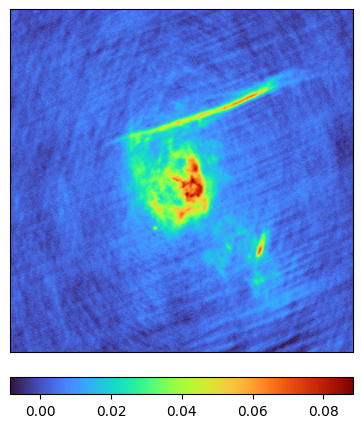

In [3]:
sgrc_res_path = "../results/multi_partition_bda_results/SGRC_MID_"

pl1_breakdown_data = []
pmsc_breakdown_data = []

partitions=["<20", "18-36", "35-57", "55-88", ">86"]
num_partitions = len(partitions)

for i in range(num_partitions):
    pl1_breakdown_data.append(util.read_csv(sgrc_res_path + "pl1/mc_timings_breakdown_" + str(i), separate_rows=True))

serial_breakdown_data = util.read_csv(sgrc_res_path + "seriall1/mc_timings_breakdown", separate_rows=True)

dirty = util.fromfits(sgrc_res_path + "seriall1/residual_0.fits")
util.plotNImages([dirty], [""], cmap="turbo", hide_ticks=True)

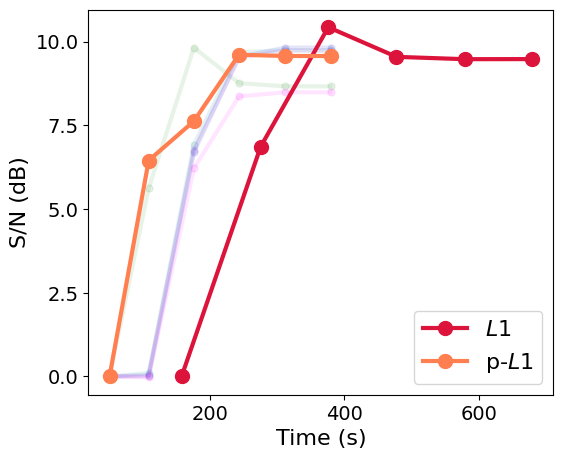

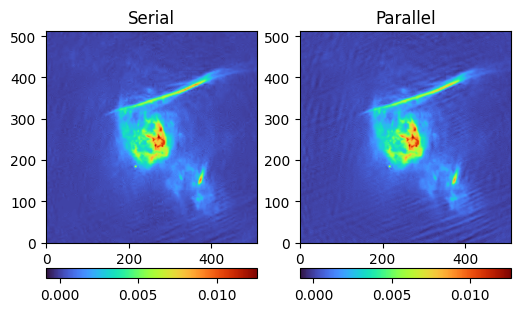

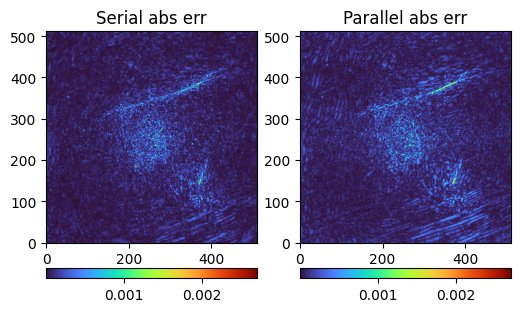

In [3]:
serial_times_sep = util.read_csv(sgrc_res_path + "seriall1/mc_timings")
serial_times = []
serial_snrs = []

parallel_times_sep = util.read_csv(sgrc_res_path + "pl1/mc_timings")
parallel_times = []
parallel_snrs = []
combined_snrs = []

best_parallel_recon = None
best_serial_recon = None
best_parallel_snr = -9999
best_serial_snr = -9999

gt = util.fromfits("../data7/SGRC_full_gt.fits")

#For serial
curr_deconv = None
time_acc = float(serial_times_sep[0])
serial_times.append(time_acc)
serial_snrs.append(0)

for i in range(0, num_mc_l1):
    curr_deconv_img = util.fromfits(sgrc_res_path + "seriall1/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(serial_times_sep[i+1])
    
    serial_snrs.append(evaluation.compute_snr(gt, curr_deconv))
    serial_times.append(time_acc)
    
    if best_serial_snr < serial_snrs[-1]:
        best_serial_recon = curr_deconv.copy()
        best_serial_snr = serial_snrs[-1]
    
    
#parallel
curr_deconvs = [None for i in range(num_partitions)]
time_acc = float(parallel_times_sep[0])
parallel_times.append(time_acc)
for i in range(num_partitions):
    parallel_snrs.append([0])

combined_snrs.append(0)

for i in range(0, num_mc_l1):
    for j in range(num_partitions):
        curr_deconv = util.fromfits(sgrc_res_path + "pl1/deconv_" + str(j) + "_" + str(i) + ".fits")
        if curr_deconvs[j] is None:
            curr_deconvs[j] = curr_deconv
        else:
            curr_deconvs[j] += curr_deconv
            
        parallel_snrs[j].append(evaluation.compute_snr(gt, curr_deconvs[j]))

    time_acc += float(parallel_times_sep[i+1])

    curr_deconv_combined = util.fromfits(sgrc_res_path + "pl1/recon_combined_" + str(i) + ".fits")
    combined_snrs.append(evaluation.compute_snr(gt, curr_deconv_combined))
    
    parallel_times.append(time_acc)
    
    if best_parallel_snr < combined_snrs[-1]:
        best_parallel_recon = curr_deconv_combined.copy()
        best_parallel_snr = combined_snrs[-1]
    
for i, p_snrs in enumerate(parallel_snrs):
    plt.plot(parallel_times, parallel_snrs[i], c=pcols[i], lw=3, alpha=0.1, marker='o', markersize=5)
    
plt.plot(serial_times, serial_snrs, c='crimson', label="$L1$", lw=3, marker='o', markersize=10)
plt.plot(parallel_times, combined_snrs, c='coral', label="p-$L1$", lw=3, marker='o', markersize=10)



plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)
#plt.yscale('log')
plt.legend(loc="lower right", fontsize=16)
plt.locator_params(nbins=5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

util.plotNImages([best_serial_recon, best_parallel_recon], ["Serial", "Parallel"], same_scale=True, cmap=cmap)
util.plotNImages([numpy.abs(gt - best_serial_recon), numpy.abs(gt - best_parallel_recon)], \
                    ["Serial abs err", "Parallel abs err"], same_scale=True, cmap=cmap)

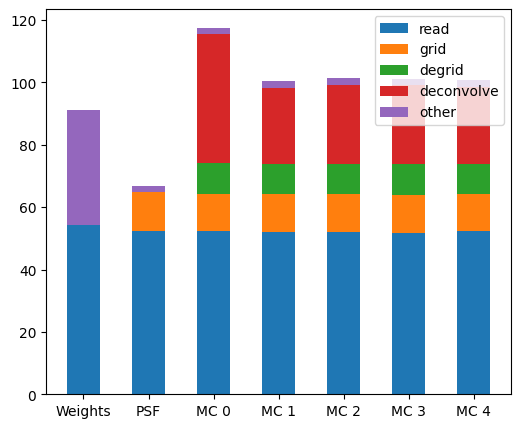

In [4]:
#Serial l1

for i, lst in enumerate(serial_breakdown_data):
    serial_breakdown_data[i] = list(map(float, lst))

serial_weights_timings = serial_breakdown_data[1]
serial_psf_timings = serial_breakdown_data[2]

serial_mc_timings = serial_breakdown_data[3:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(serial_mc_timings) + 2)
    
fig, ax = plt.subplots()

average_deconv = 0

timings = []
timings.append([serial_weights_timings[0], 0, 0, 0, sum(serial_weights_timings[1:])])
timings.append([serial_psf_timings[0], serial_psf_timings[3], 0, 0, sum(serial_psf_timings[1:3]) + serial_psf_timings[4]])

for i, curr_mc_timings in enumerate(serial_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[1:4]) + curr_mc_timings[5] + curr_mc_timings[7]
    timings.append([curr_mc_timings[0], curr_mc_timings[6], curr_mc_timings[4], curr_mc_timings[8], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])
    
    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
sgrc_timings_serial = total_timings(timings, breakdowns)
    
ax.legend(loc="upper right")
plt.show()

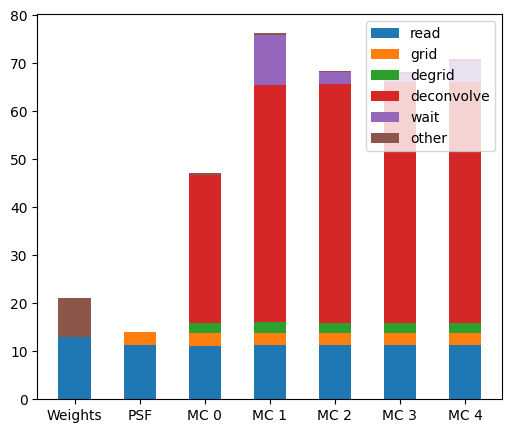

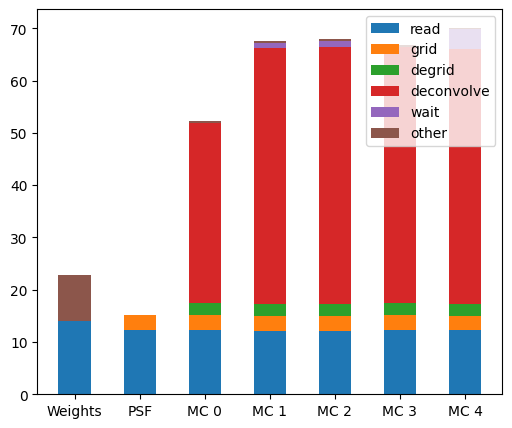

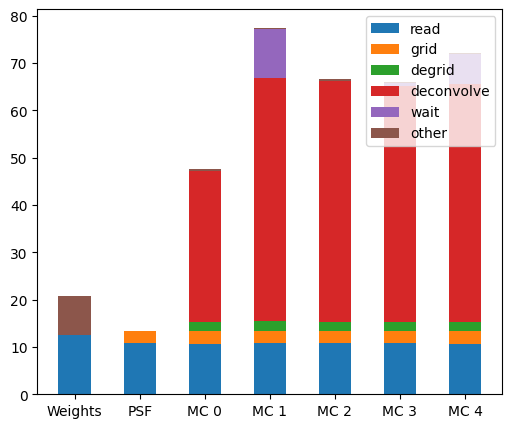

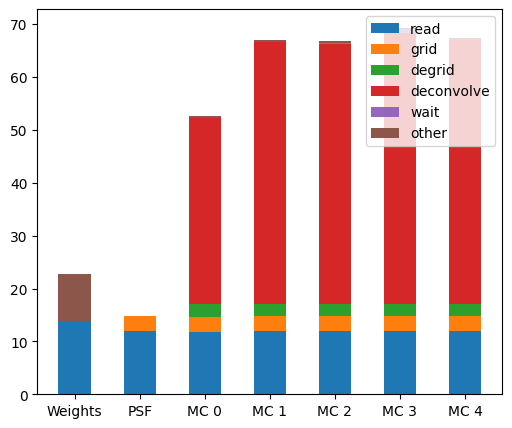

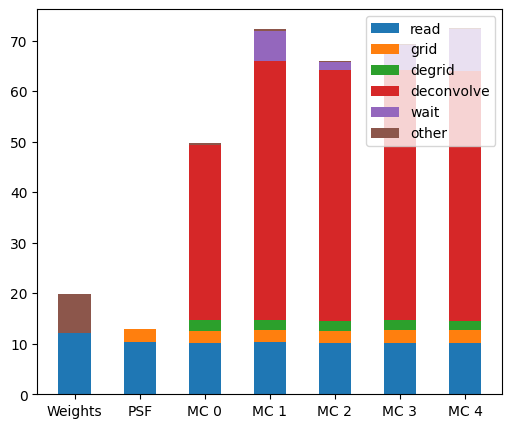

In [5]:
#Parallel l1

sgrc_pl1_timings = []

for pl1_node in pl1_breakdown_data:
    breakdown_data = []
    for i, lst in enumerate(pl1_node):
        breakdown_data.append(list(map(float, lst)))
    
    weights_timings = breakdown_data[1]
    psf_timings = breakdown_data[2]
    wait_timings = breakdown_data[3]
    mc_timings = breakdown_data[4:]
    
    width = 0.5
    
    labels = [
        "Weights",
        "PSF"
    ]
        
    bottom = numpy.zeros(len(mc_timings) + 2)
        
    fig, ax = plt.subplots()
    
    timings = []
    timings.append([weights_timings[0], 0, 0, 0, 0, sum(weights_timings[1:])])
    timings.append([psf_timings[0], psf_timings[3], 0, 0, 0, sum(psf_timings[1:2]) + psf_timings[4]])
    
    for i, curr_mc_timings in enumerate(mc_timings):
        labels.append("MC " + str(i))
        other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
        timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                        curr_mc_timings[0] + curr_mc_timings[10], other_timings])
        
    for i, curr_breakdown in enumerate(breakdowns_parallel):
        curr_breakdown_timing = []
        for curr_timing in timings:
            curr_breakdown_timing.append(curr_timing[i])
    
        p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
        bottom += curr_breakdown_timing
        
    sgrc_pl1_timings.append(total_timings(timings, breakdowns_parallel))
        
    ax.legend(loc="upper right")
    plt.show()

## And for a (much) larger DB (SKA MID)

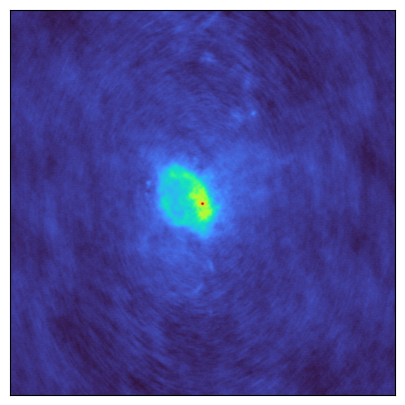

In [6]:
sgra_res_path = "../results/multi_partition_bda_results/SGRA_full_averaged_"

pl1_breakdown_data = []
pmsc_breakdown_data = []

partitions=["<15", "13-28", "26-49", "47-87", ">85"]
num_partitions = len(partitions)

for i in range(num_partitions):
    pl1_breakdown_data.append(util.read_csv(sgra_res_path + "pl1/mc_timings_breakdown_" + str(i), separate_rows=True))

serial_breakdown_data = util.read_csv(sgra_res_path + "seriall1/mc_timings_breakdown", separate_rows=True)

dirty = util.fromfits(sgra_res_path + "seriall1/residual_0.fits")
util.plotNImages([dirty], [""], show_cbar=False, cmap="turbo", hide_ticks=True, output_file="../figures/dirty.png")

sgra_total_times = []

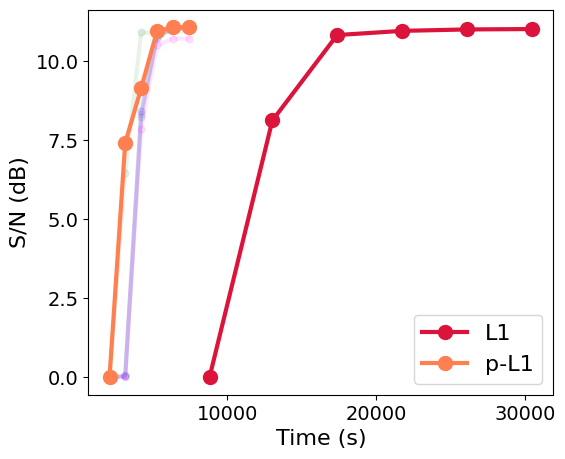

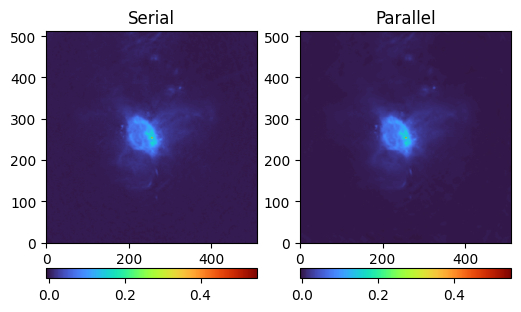

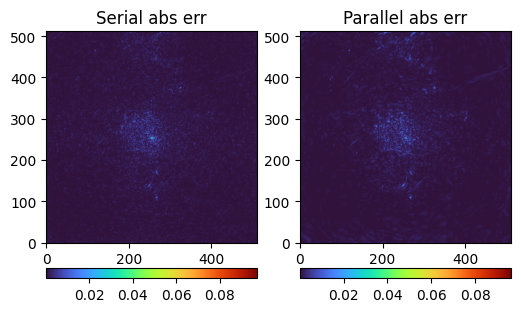

In [7]:
serial_times_sep = util.read_csv(sgra_res_path + "seriall1/mc_timings")
serial_times = []
serial_snrs = []

parallel_times_sep = util.read_csv(sgra_res_path + "pl1/mc_timings")
parallel_times = []
parallel_snrs = []
combined_snrs = []

best_parallel_recon = None
best_serial_recon = None
best_parallel_snr = -9999
best_serial_snr = -9999

gt = util.fromfits("../data7/SGRA_full_gt.fits")

#For serial
curr_deconv = None
time_acc = float(serial_times_sep[0])
serial_times.append(time_acc)
serial_snrs.append(0)

for i in range(0, num_mc_l1):
    curr_deconv_img = util.fromfits(sgra_res_path + "seriall1/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(serial_times_sep[i+1])
    
    serial_snrs.append(evaluation.compute_snr(gt, curr_deconv))
    serial_times.append(time_acc)
    
    if best_serial_snr < serial_snrs[-1]:
        best_serial_recon = curr_deconv.copy()
        best_serial_snr = serial_snrs[-1]

sgra_total_times.append(serial_times[-1])
    
#parallel
curr_deconvs = [None for i in range(num_partitions)]
time_acc = float(parallel_times_sep[0])
parallel_times.append(time_acc)
for i in range(num_partitions):
    parallel_snrs.append([0])

combined_snrs.append(0)

for i in range(0, num_mc_l1):
    for j in range(num_partitions):
        curr_deconv = util.fromfits(sgra_res_path + "pl1/deconv_" + str(j) + "_" + str(i) + ".fits")
        if curr_deconvs[j] is None:
            curr_deconvs[j] = curr_deconv
        else:
            curr_deconvs[j] += curr_deconv
            
        parallel_snrs[j].append(evaluation.compute_snr(gt, curr_deconvs[j]))

    time_acc += float(parallel_times_sep[i+1])

    curr_deconv_combined = util.fromfits(sgra_res_path + "pl1/recon_combined_" + str(i) + ".fits")
    combined_snrs.append(evaluation.compute_snr(gt, curr_deconv_combined))
    
    parallel_times.append(time_acc)
    
    if best_parallel_snr < combined_snrs[-1]:
        best_parallel_recon = curr_deconv_combined.copy()
        best_parallel_snr = combined_snrs[-1]

sgra_total_times.append(parallel_times[-1])
    
for i, p_snrs in enumerate(parallel_snrs):
    plt.plot(parallel_times, parallel_snrs[i], c=pcols[i], lw=3, alpha=0.1, marker='o', markersize=5)
    
plt.plot(serial_times, serial_snrs, c='crimson', label="L1", lw=3, marker='o', markersize=10)
plt.plot(parallel_times, combined_snrs, c='coral', label="p-L1", lw=3, marker='o', markersize=10)



plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)
#plt.yscale('log')
plt.legend(loc="lower right", fontsize=16)
plt.locator_params(nbins=5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig("../figures/recon5part.png", pad_inches=0.0, bbox_inches='tight')

util.plotNImages([best_serial_recon, best_parallel_recon], ["Serial", "Parallel"], same_scale=False, cmap=cmap, output_file="../figures/recon5partrecons.png")
util.plotNImages([numpy.abs(gt - best_serial_recon), numpy.abs(gt - best_parallel_recon)], \
                    ["Serial abs err", "Parallel abs err"], same_scale=False, cmap=cmap, output_file="../figures/recon5parterrs.png")

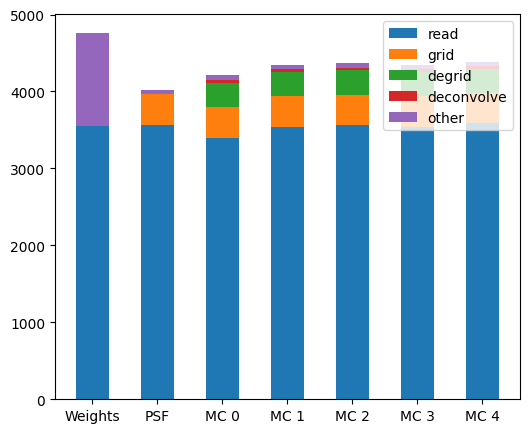

In [8]:
#Serial l1

for i, lst in enumerate(serial_breakdown_data):
    serial_breakdown_data[i] = list(map(float, lst))

serial_weights_timings = serial_breakdown_data[1]
serial_psf_timings = serial_breakdown_data[2]

serial_mc_timings = serial_breakdown_data[3:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(serial_mc_timings) + 2)
    
fig, ax = plt.subplots()

average_deconv = 0

timings = []
timings.append([serial_weights_timings[0], 0, 0, 0, sum(serial_weights_timings[1:])])
timings.append([serial_psf_timings[0], serial_psf_timings[3], 0, 0, sum(serial_psf_timings[1:3]) + serial_psf_timings[4]])

for i, curr_mc_timings in enumerate(serial_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[1:4]) + curr_mc_timings[5] + curr_mc_timings[7]
    timings.append([curr_mc_timings[0], curr_mc_timings[6], curr_mc_timings[4], curr_mc_timings[8], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])
    
    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
sgra_timings_serial = total_timings(timings, breakdowns)
    
ax.legend(loc="upper right")
plt.show()

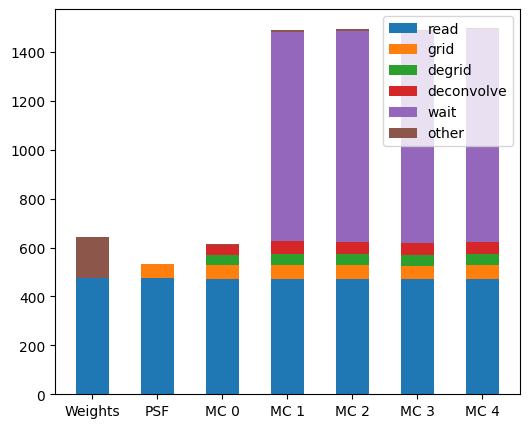

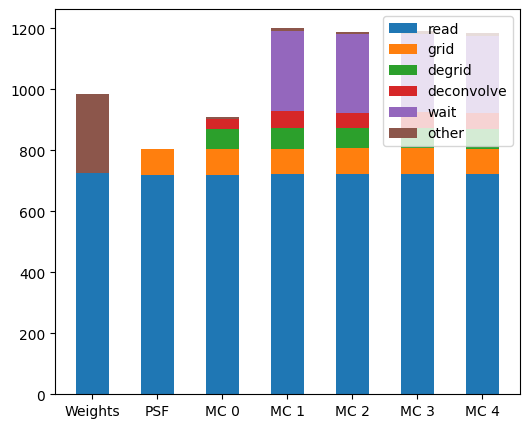

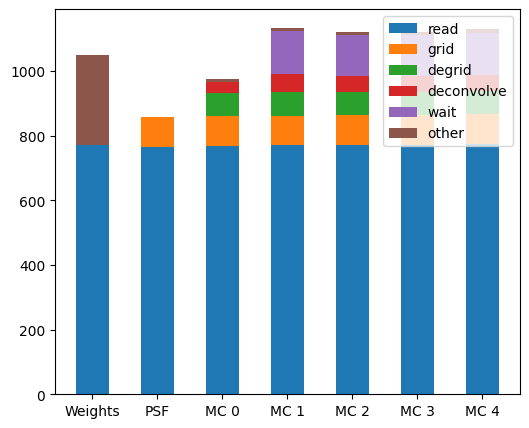

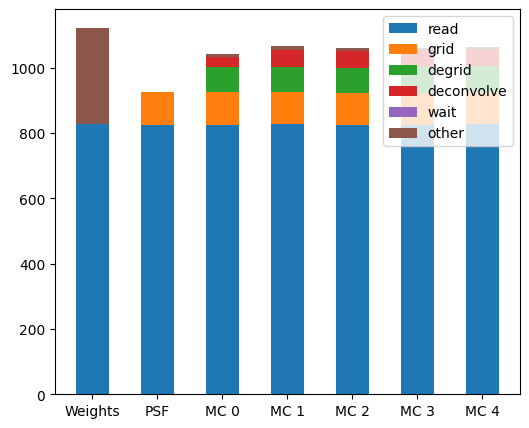

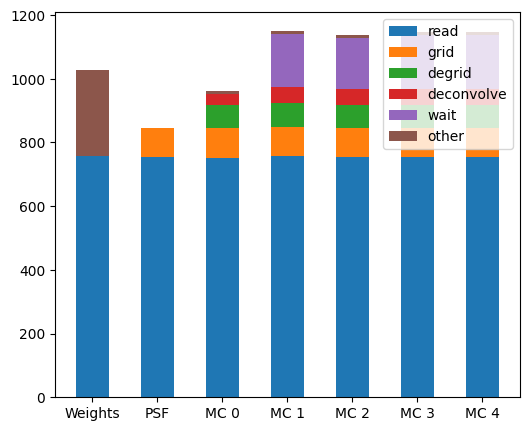

In [9]:
#Parallel l1

sgra_pl1_timings = []

for pl1_node in pl1_breakdown_data:
    breakdown_data = []
    for i, lst in enumerate(pl1_node):
        breakdown_data.append(list(map(float, lst)))
    
    weights_timings = breakdown_data[1]
    psf_timings = breakdown_data[2]
    wait_timings = breakdown_data[3]
    mc_timings = breakdown_data[4:]
    
    width = 0.5
    
    labels = [
        "Weights",
        "PSF"
    ]
        
    bottom = numpy.zeros(len(mc_timings) + 2)
        
    fig, ax = plt.subplots()
    
    timings = []
    timings.append([weights_timings[0], 0, 0, 0, 0, sum(weights_timings[1:])])
    timings.append([psf_timings[0], psf_timings[3], 0, 0, 0, sum(psf_timings[1:2]) + psf_timings[4]])
    
    for i, curr_mc_timings in enumerate(mc_timings):
        labels.append("MC " + str(i))
        other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
        timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                        curr_mc_timings[0] + curr_mc_timings[10], other_timings])
        
    for i, curr_breakdown in enumerate(breakdowns_parallel):
        curr_breakdown_timing = []
        for curr_timing in timings:
            curr_breakdown_timing.append(curr_timing[i])
    
        p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
        bottom += curr_breakdown_timing
        
    sgra_pl1_timings.append(total_timings(timings, breakdowns_parallel))
        
    ax.legend(loc="upper right")
    plt.show()

## And for SKA-LOW with a large DB

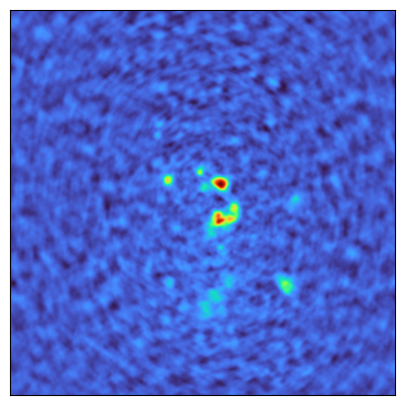

In [10]:
sgrb_res_path = "../results/multi_partition_bda_results/SGRB_full_averaged_"

pl1_breakdown_data = []
pmsc_breakdown_data = []

partitions=["<35", "33-54", "52-73", "72-97", ">95"]
num_partitions = len(partitions)

for i in range(num_partitions):
    pl1_breakdown_data.append(util.read_csv(sgrb_res_path + "pl1/mc_timings_breakdown_" + str(i), separate_rows=True))

serial_breakdown_data = util.read_csv(sgrb_res_path + "seriall1/mc_timings_breakdown", separate_rows=True)

dirty = util.fromfits(sgrb_res_path + "seriall1/residual_0.fits")
util.plotNImages([dirty], [""], show_cbar=False, cmap="turbo", hide_ticks=True, output_file="../figures/dirty1.png")

sgrb_total_times = []

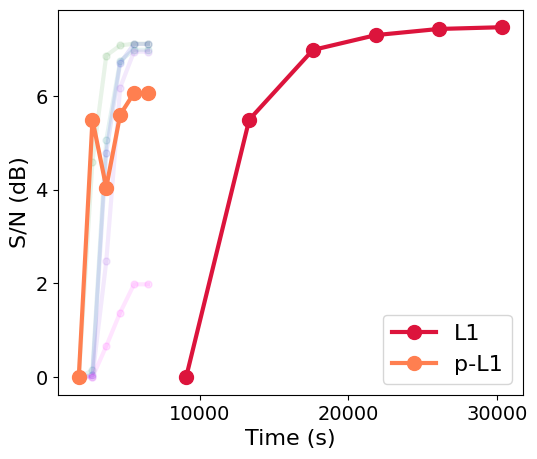

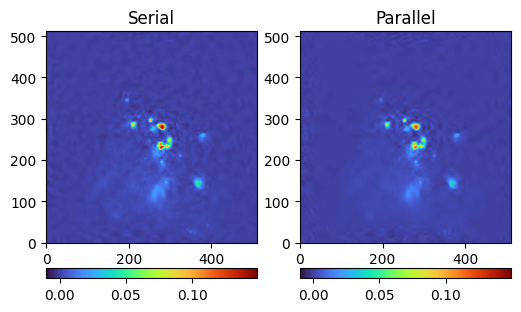

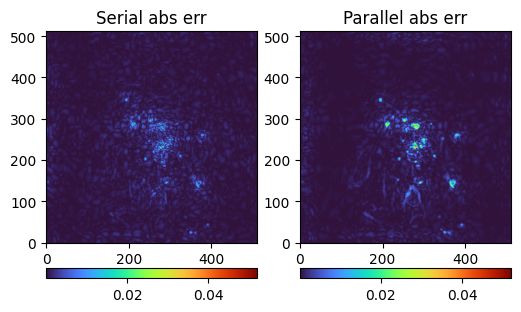

[[0, 4.6017378763965, 6.860362031567087, 7.078028910761295, 7.1147879105520575, 7.1147879105520575], [0, 0.1477922569761679, 5.062191834086117, 6.74759581657074, 6.986392187920459, 6.986392187920459], [0, 0.04228894668004908, 4.793166294230326, 6.70073459124386, 7.1077457958696435, 7.1077457958696435], [0, 0.006634150057783034, 2.470358893350004, 6.179250120019538, 6.9455219074070715, 6.9455219074070715], [0, 0.0013042943301906948, 0.6625204584730207, 1.3787584103507649, 1.9816554766497392, 1.9816554766497392]]


In [11]:
serial_times_sep = util.read_csv(sgrb_res_path + "seriall1/mc_timings")
serial_times = []
serial_snrs = []

parallel_times_sep = util.read_csv(sgrb_res_path + "pl1/mc_timings")
parallel_times = []
parallel_snrs = []
combined_snrs = []

best_parallel_recon = None
best_serial_recon = None
best_parallel_snr = -9999
best_serial_snr = -9999

gt = util.fromfits("../data7/SGRB_full_gt.fits")

#For serial
curr_deconv = None
time_acc = float(serial_times_sep[0])
serial_times.append(time_acc)
serial_snrs.append(0)

for i in range(0, num_mc_l1):
    curr_deconv_img = util.fromfits(sgrb_res_path + "seriall1/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(serial_times_sep[i+1])
    
    serial_snrs.append(evaluation.compute_snr(gt, curr_deconv))
    serial_times.append(time_acc)
    
    if True: #best_serial_snr < serial_snrs[-1]:
        best_serial_recon = curr_deconv.copy()
        best_serial_snr = serial_snrs[-1]

sgrb_total_times.append(serial_times[-1])
    
#parallel
curr_deconvs = [None for i in range(num_partitions)]
time_acc = float(parallel_times_sep[0])
parallel_times.append(time_acc)
for i in range(num_partitions):
    parallel_snrs.append([0])

combined_snrs.append(0)

for i in range(0, num_mc_l1):
    for j in range(num_partitions):
        curr_deconv = util.fromfits(sgrb_res_path + "pl1/deconv_" + str(j) + "_" + str(i) + ".fits")
        if curr_deconvs[j] is None:
            curr_deconvs[j] = curr_deconv
        else:
            curr_deconvs[j] += curr_deconv
            
        parallel_snrs[j].append(evaluation.compute_snr(gt, curr_deconvs[j]))

    time_acc += float(parallel_times_sep[i+1])

    curr_deconv_combined = util.fromfits(sgrb_res_path + "pl1/recon_combined_" + str(i) + ".fits")
    combined_snrs.append(evaluation.compute_snr(gt, curr_deconv_combined))
    
    parallel_times.append(time_acc)
    
    if True: #best_parallel_snr < combined_snrs[-1]:
        best_parallel_recon = curr_deconv_combined.copy()
        best_parallel_snr = combined_snrs[-1]

sgrb_total_times.append(parallel_times[-1])
    
for i, p_snrs in enumerate(parallel_snrs):
    plt.plot(parallel_times, parallel_snrs[i], c=pcols[i], lw=3, alpha=0.1, marker='o', markersize=5)
    
plt.plot(serial_times, serial_snrs, c='crimson', label="L1", lw=3, marker='o', markersize=10)
plt.plot(parallel_times, combined_snrs, c='coral', label="p-L1", lw=3, marker='o', markersize=10)



plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)
#plt.yscale('log')
plt.legend(loc="lower right", fontsize=16)
plt.locator_params(nbins=5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig("../figures/recon5partb.png", pad_inches=0.0, bbox_inches='tight')

util.plotNImages([best_serial_recon, best_parallel_recon], ["Serial", "Parallel"], same_scale=True, cmap=cmap, output_file="../figures/recon5partbrecons.png")
util.plotNImages([numpy.abs(gt - best_serial_recon), numpy.abs(gt - best_parallel_recon)], \
                    ["Serial abs err", "Parallel abs err"], same_scale=True, cmap=cmap)

print(parallel_snrs)

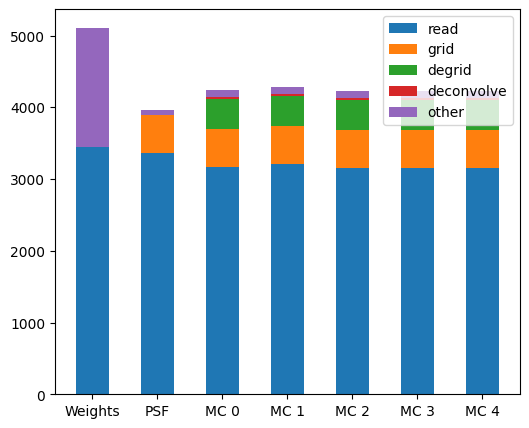

In [12]:
#Serial l1

for i, lst in enumerate(serial_breakdown_data):
    serial_breakdown_data[i] = list(map(float, lst))

serial_weights_timings = serial_breakdown_data[1]
serial_psf_timings = serial_breakdown_data[2]

serial_mc_timings = serial_breakdown_data[3:]

width = 0.5

labels = [
    "Weights",
    "PSF"
]
    
bottom = numpy.zeros(len(serial_mc_timings) + 2)
    
fig, ax = plt.subplots()

average_deconv = 0

timings = []
timings.append([serial_weights_timings[0], 0, 0, 0, sum(serial_weights_timings[1:])])
timings.append([serial_psf_timings[0], serial_psf_timings[3], 0, 0, sum(serial_psf_timings[1:3]) + serial_psf_timings[4]])

for i, curr_mc_timings in enumerate(serial_mc_timings):
    labels.append("MC " + str(i))
    other_timings = sum(curr_mc_timings[1:4]) + curr_mc_timings[5] + curr_mc_timings[7]
    timings.append([curr_mc_timings[0], curr_mc_timings[6], curr_mc_timings[4], curr_mc_timings[8], other_timings])
    
for i, curr_breakdown in enumerate(breakdowns):
    curr_breakdown_timing = []
    for curr_timing in timings:
        curr_breakdown_timing.append(curr_timing[i])
    
    p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
    bottom += curr_breakdown_timing
    
sgrb_timings_serial = total_timings(timings, breakdowns)
    
ax.legend(loc="upper right")
plt.show()

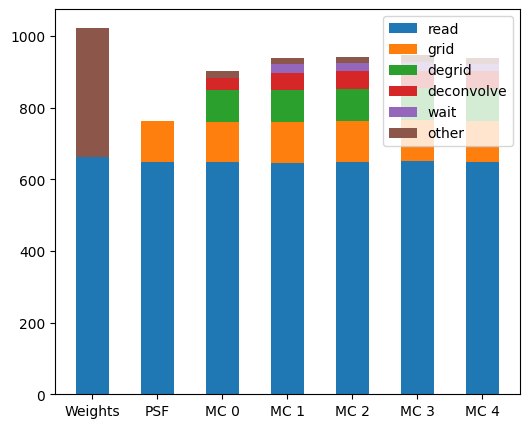

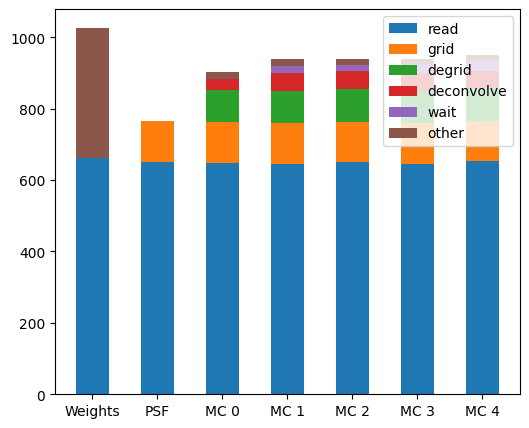

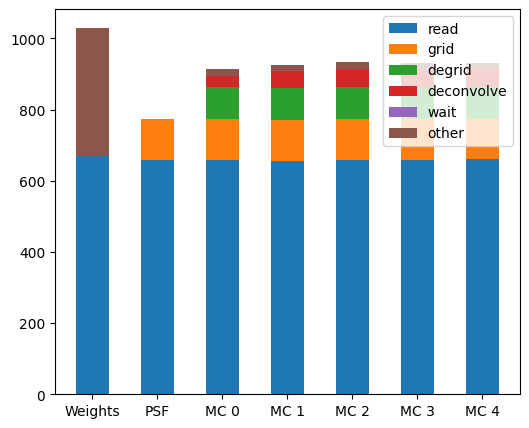

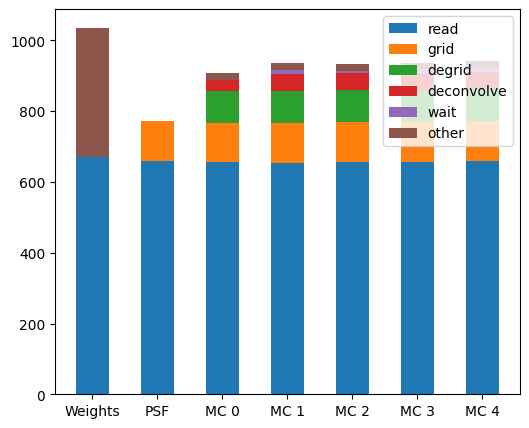

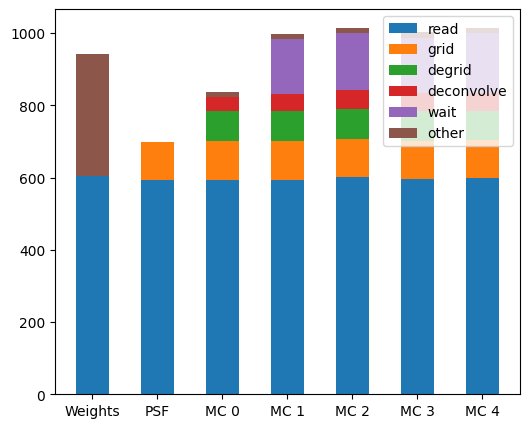

In [13]:
#Parallel l1

sgrb_pl1_timings = []

for pl1_node in pl1_breakdown_data:
    breakdown_data = []
    for i, lst in enumerate(pl1_node):
        breakdown_data.append(list(map(float, lst)))
    
    weights_timings = breakdown_data[1]
    psf_timings = breakdown_data[2]
    wait_timings = breakdown_data[3]
    mc_timings = breakdown_data[4:]
    
    width = 0.5
    
    labels = [
        "Weights",
        "PSF"
    ]
        
    bottom = numpy.zeros(len(mc_timings) + 2)
        
    fig, ax = plt.subplots()
    
    timings = []
    timings.append([weights_timings[0], 0, 0, 0, 0, sum(weights_timings[1:])])
    timings.append([psf_timings[0], psf_timings[3], 0, 0, 0, sum(psf_timings[1:2]) + psf_timings[4]])
    
    for i, curr_mc_timings in enumerate(mc_timings):
        labels.append("MC " + str(i))
        other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
        timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                        curr_mc_timings[0] + curr_mc_timings[10], other_timings])
        
    for i, curr_breakdown in enumerate(breakdowns_parallel):
        curr_breakdown_timing = []
        for curr_timing in timings:
            curr_breakdown_timing.append(curr_timing[i])
    
        p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
        bottom += curr_breakdown_timing
        
    sgrb_pl1_timings.append(total_timings(timings, breakdowns_parallel))
        
    ax.legend(loc="upper right")
    plt.show()

## And for 10 partitions:

### SGRA

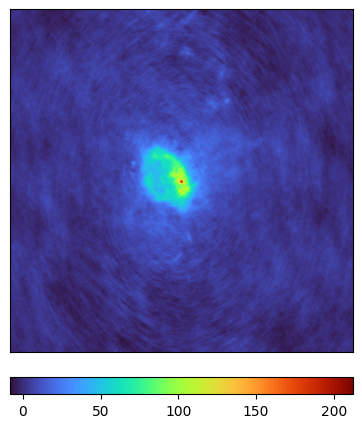

In [14]:
sgra_res_path = "../results/multi_partition_bda_results/SGRA_full_averaged_"
sgra10_res_path = "../results/multi_partition_bda_results/SGRA_full_averaged10_"

pl1_breakdown_data = []
pmsc_breakdown_data = []

partitions=["<10", "8-15", "13-21", "19-28", "26-37", "35-49", "47-69", "67-87", "85-110", ">110"]
num_partitions = len(partitions)

for i in range(num_partitions):
    pl1_breakdown_data.append(util.read_csv(sgra10_res_path + "pl1/mc_timings_breakdown_" + str(i), separate_rows=True))

serial_breakdown_data = util.read_csv(sgra_res_path + "seriall1/mc_timings_breakdown", separate_rows=True)

dirty = util.fromfits(sgra_res_path + "seriall1/residual_0.fits")
util.plotNImages([dirty], [""], cmap="turbo", hide_ticks=True)

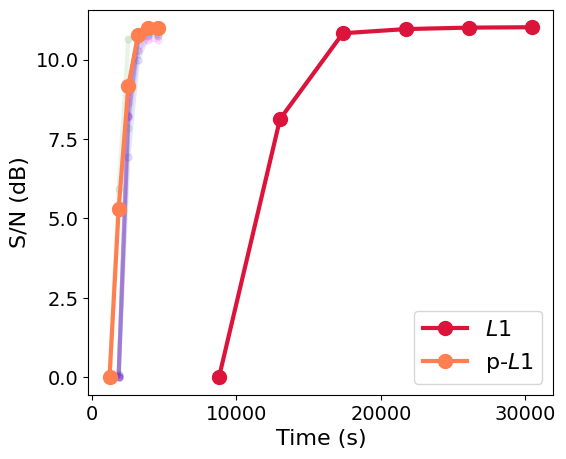

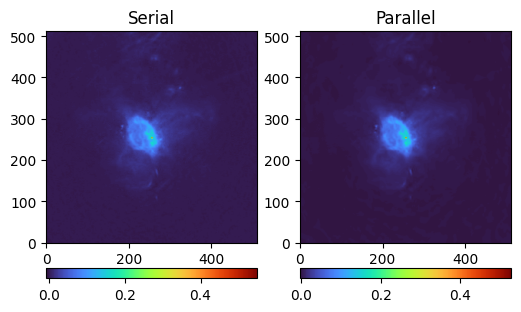

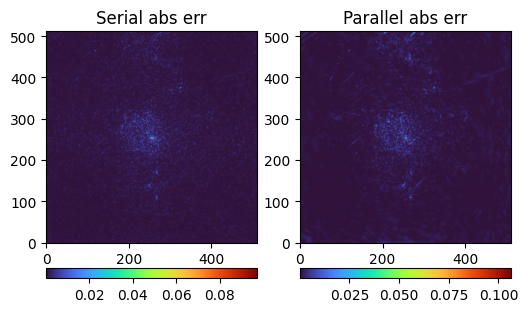

In [15]:
serial_times_sep = util.read_csv(sgra_res_path + "seriall1/mc_timings")
serial_times = []
serial_snrs = []

parallel_times_sep = util.read_csv(sgra10_res_path + "pl1/mc_timings")
parallel_times = []
parallel_snrs = []
combined_snrs = []

best_parallel_recon = None
best_serial_recon = None
best_parallel_snr = -9999
best_serial_snr = -9999

gt = util.fromfits("../data7/SGRA_full_gt.fits")

#For serial
curr_deconv = None
time_acc = float(serial_times_sep[0])
serial_times.append(time_acc)
serial_snrs.append(0)

for i in range(0, num_mc_l1):
    curr_deconv_img = util.fromfits(sgra_res_path + "seriall1/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(serial_times_sep[i+1])
    
    serial_snrs.append(evaluation.compute_snr(gt, curr_deconv))
    serial_times.append(time_acc)
    
    if best_serial_snr < serial_snrs[-1]:
        best_serial_recon = curr_deconv.copy()
        best_serial_snr = serial_snrs[-1]
    
    
#parallel
curr_deconvs = [None for i in range(num_partitions)]
time_acc = float(parallel_times_sep[0])
parallel_times.append(time_acc)
for i in range(num_partitions):
    parallel_snrs.append([0])

combined_snrs.append(0)

for i in range(0, num_mc_l1):
    for j in range(num_partitions):
        curr_deconv = util.fromfits(sgra10_res_path + "pl1/deconv_" + str(j) + "_" + str(i) + ".fits")
        if curr_deconvs[j] is None:
            curr_deconvs[j] = curr_deconv
        else:
            curr_deconvs[j] += curr_deconv
            
        parallel_snrs[j].append(evaluation.compute_snr(gt, curr_deconvs[j]))

    time_acc += float(parallel_times_sep[i+1])

    curr_deconv_combined = util.fromfits(sgra10_res_path + "pl1/recon_combined_" + str(i) + ".fits")
    combined_snrs.append(evaluation.compute_snr(gt, curr_deconv_combined))
    
    parallel_times.append(time_acc)
    
    if best_parallel_snr < combined_snrs[-1]:
        best_parallel_recon = curr_deconv_combined.copy()
        best_parallel_snr = combined_snrs[-1]

sgra_total_times.append(parallel_times[-1])
    
for i, p_snrs in enumerate(parallel_snrs):
    plt.plot(parallel_times, parallel_snrs[i], c=pcols[i], lw=3, alpha=0.1, marker='o', markersize=5)
    
plt.plot(serial_times, serial_snrs, c='crimson', label="$L1$", lw=3, marker='o', markersize=10)
plt.plot(parallel_times, combined_snrs, c='coral', label="p-$L1$", lw=3, marker='o', markersize=10)



plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)
#plt.yscale('log')
plt.legend(loc="lower right", fontsize=16)
plt.locator_params(nbins=5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig("../figures/recon10part.png", pad_inches=0.0, bbox_inches='tight')

util.plotNImages([best_serial_recon, best_parallel_recon], ["Serial", "Parallel"], same_scale=False, cmap=cmap)
util.plotNImages([numpy.abs(gt - best_serial_recon), numpy.abs(gt - best_parallel_recon)], \
                    ["Serial abs err", "Parallel abs err"], same_scale=False, cmap=cmap)

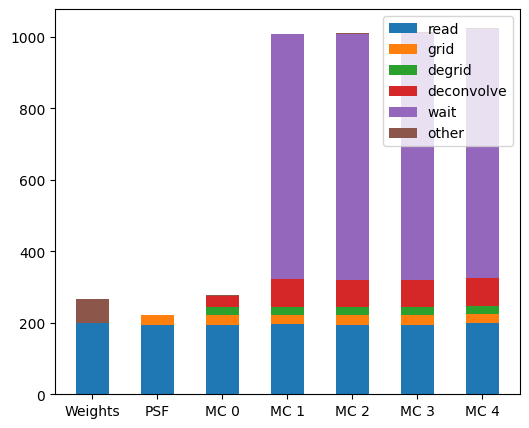

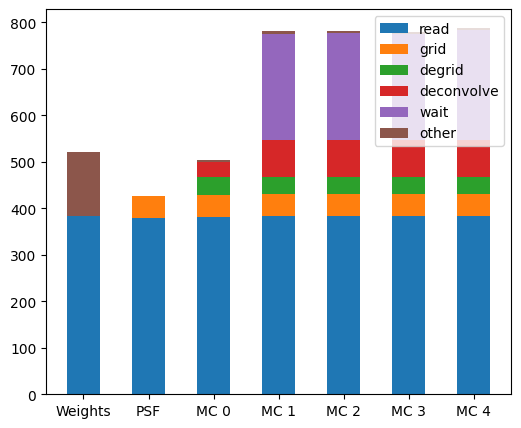

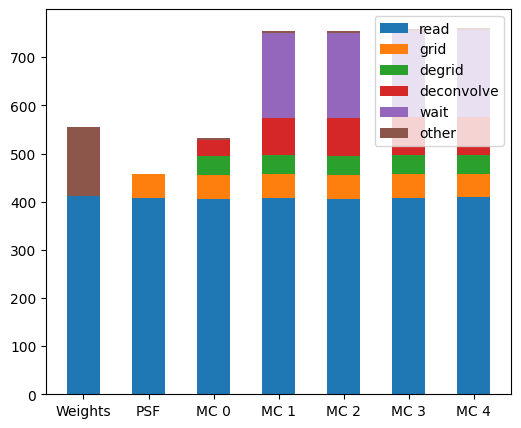

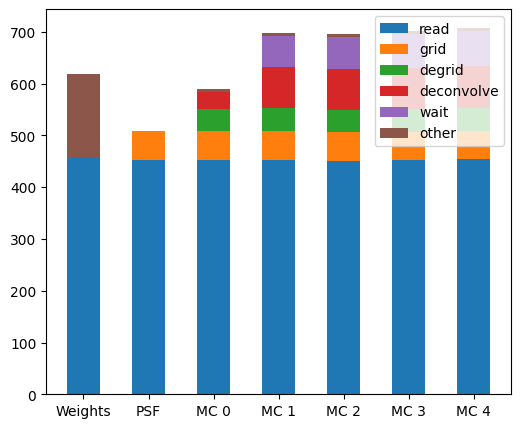

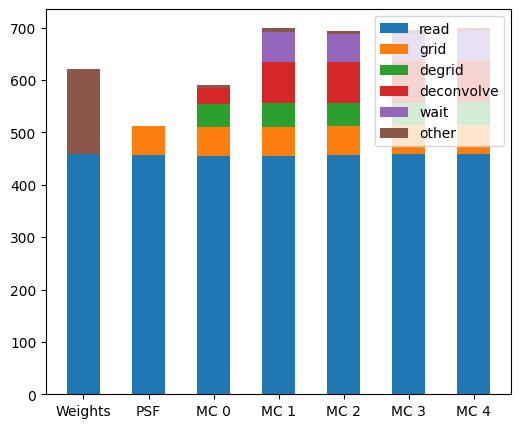

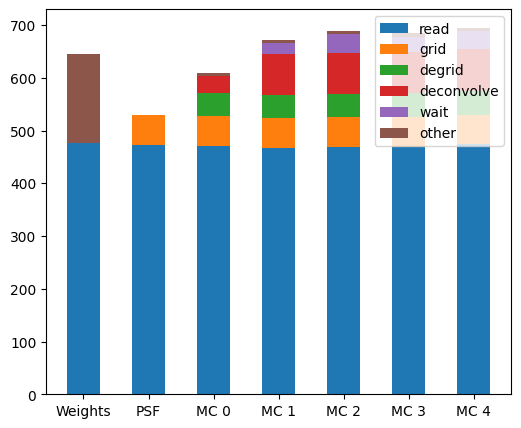

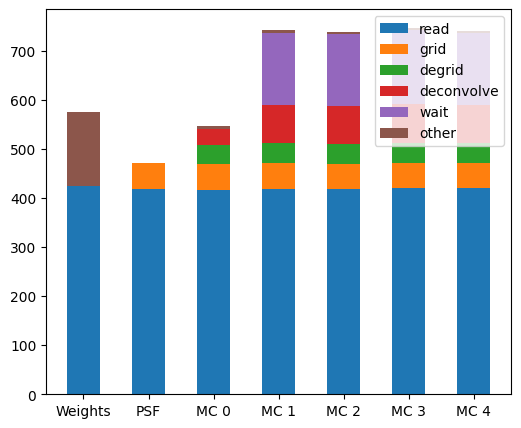

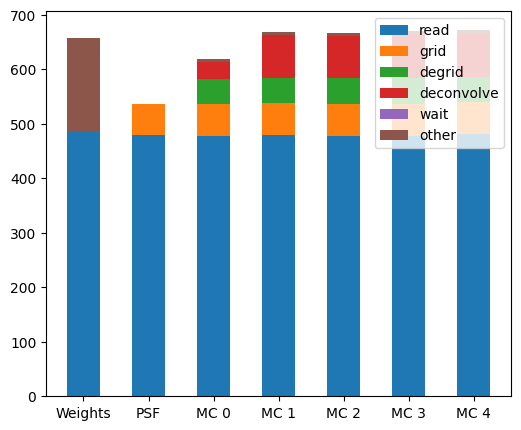

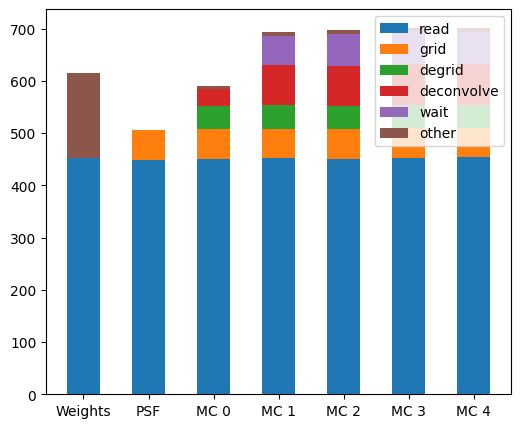

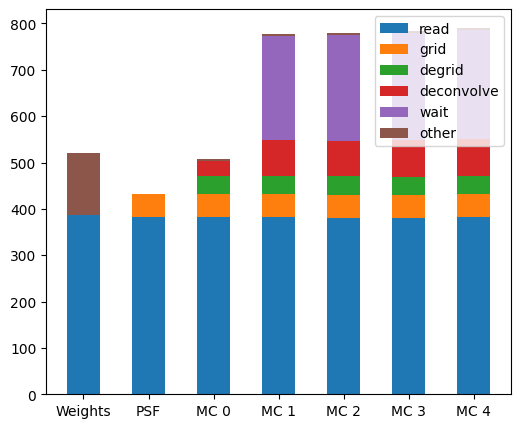

In [16]:
#Parallel l1

sgra10_pl1_timings = []

for pl1_node in pl1_breakdown_data:
    breakdown_data = []
    for i, lst in enumerate(pl1_node):
        breakdown_data.append(list(map(float, lst)))
    
    weights_timings = breakdown_data[1]
    psf_timings = breakdown_data[2]
    wait_timings = breakdown_data[3]
    mc_timings = breakdown_data[4:]
    
    width = 0.5
    
    labels = [
        "Weights",
        "PSF"
    ]
        
    bottom = numpy.zeros(len(mc_timings) + 2)
        
    fig, ax = plt.subplots()
    
    timings = []
    timings.append([weights_timings[0], 0, 0, 0, 0, sum(weights_timings[1:])])
    timings.append([psf_timings[0], psf_timings[3], 0, 0, 0, sum(psf_timings[1:2]) + psf_timings[4]])
    
    for i, curr_mc_timings in enumerate(mc_timings):
        labels.append("MC " + str(i))
        other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
        timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                        curr_mc_timings[0] + curr_mc_timings[10], other_timings])
        
    for i, curr_breakdown in enumerate(breakdowns_parallel):
        curr_breakdown_timing = []
        for curr_timing in timings:
            curr_breakdown_timing.append(curr_timing[i])
    
        p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
        bottom += curr_breakdown_timing
        
    sgra10_pl1_timings.append(total_timings(timings, breakdowns_parallel))
        
    ax.legend(loc="upper right")
    plt.show()

## SGRB

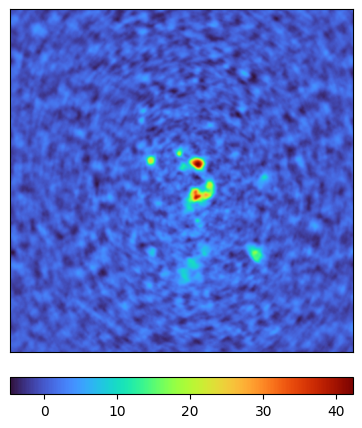

In [17]:
sgrb_res_path = "../results/multi_partition_bda_results/SGRB_full_averaged_"
sgrb10_res_path = "../results/multi_partition_bda_results/SGRB_full_averaged10_"

pl1_breakdown_data = []
pmsc_breakdown_data = []

partitions=["<24", "23-35", "33-43", "41-54", "52-59", "57-73", "71-88", "86-97", "95-124", ">122"]
num_partitions = len(partitions)

for i in range(num_partitions):
    pl1_breakdown_data.append(util.read_csv(sgrb10_res_path + "pl1/mc_timings_breakdown_" + str(i), separate_rows=True))

serial_breakdown_data = util.read_csv(sgrb_res_path + "seriall1/mc_timings_breakdown", separate_rows=True)

dirty = util.fromfits(sgrb_res_path + "seriall1/residual_0.fits")
util.plotNImages([dirty], [""], cmap="turbo", hide_ticks=True)

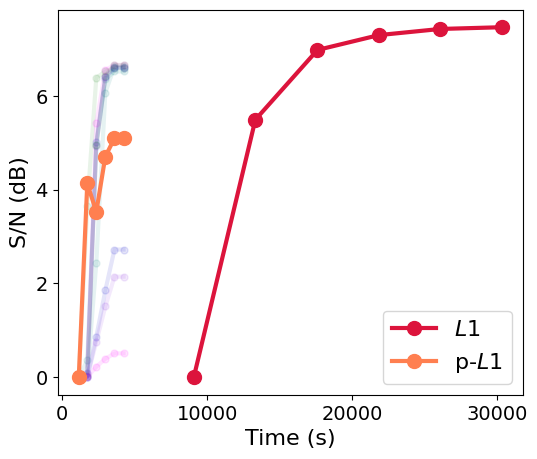

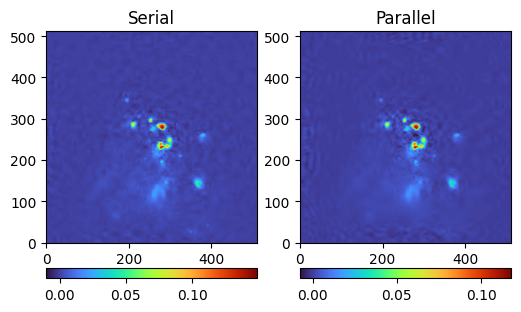

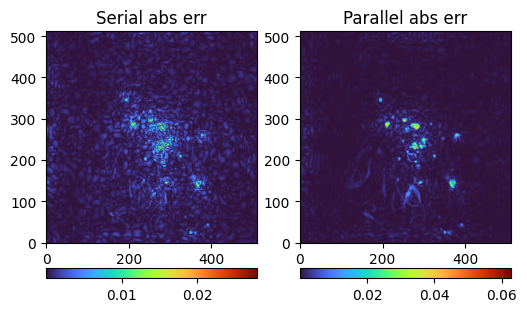

[[0, 3.6578950921164513, 6.388768480850548, 6.521659578608635, 6.599065384190577, 6.599065384190577], [0, 0.3606439188304912, 4.9641799518479734, 6.359783400651075, 6.521745219965938, 6.521745219965938], [0, 0.09714877294518685, 5.0139016574103366, 6.398301787154608, 6.596608162148439, 6.596608162148439], [0, 0.0669380778168985, 4.9240906804093125, 6.414224566819281, 6.618389778754958, 6.618389778754958], [0, 0.02083493077169428, 5.421346934176397, 6.553731550817904, 6.662293380835692, 6.662293380835692], [0, 0.024254588743525332, 4.945000700958198, 6.426864379641092, 6.660007256332373, 6.660007256332373], [0, 0.004936956111074883, 2.4356414419153394, 6.072794021317087, 6.623264396378681, 6.623264396378681], [0, 0.0018913080148080968, 0.8638729150155979, 1.852022202060599, 2.7241212448055316, 2.7241212448055316], [0, 0.0015368148336806443, 0.7575421684329131, 1.5086272178920952, 2.1457530222785275, 2.1457530222785275], [0, -0.00015248864424138522, 0.22227128117244416, 0.392822041283257

In [18]:
serial_times_sep = util.read_csv(sgrb_res_path + "seriall1/mc_timings")
serial_times = []
serial_snrs = []

parallel_times_sep = util.read_csv(sgrb10_res_path + "pl1/mc_timings")
parallel_times = []
parallel_snrs = []
combined_snrs = []

best_parallel_recon = None
best_serial_recon = None
best_parallel_snr = -9999
best_serial_snr = -9999

gt = util.fromfits("../data7/SGRB_full_gt.fits")

#For serial
curr_deconv = None
time_acc = float(serial_times_sep[0])
serial_times.append(time_acc)
serial_snrs.append(0)

for i in range(0, num_mc_l1):
    curr_deconv_img = util.fromfits(sgrb_res_path + "seriall1/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(serial_times_sep[i+1])
    
    serial_snrs.append(evaluation.compute_snr(gt, curr_deconv))
    serial_times.append(time_acc)
    
    if best_serial_snr < serial_snrs[-1]:
        best_serial_recon = curr_deconv.copy()
        best_serial_snr = serial_snrs[-1]
    
    
#parallel
curr_deconvs = [None for i in range(num_partitions)]
time_acc = float(parallel_times_sep[0])
parallel_times.append(time_acc)
for i in range(num_partitions):
    parallel_snrs.append([0])

combined_snrs.append(0)

for i in range(0, num_mc_l1):
    for j in range(num_partitions):
        curr_deconv = util.fromfits(sgrb10_res_path + "pl1/deconv_" + str(j) + "_" + str(i) + ".fits")
        if curr_deconvs[j] is None:
            curr_deconvs[j] = curr_deconv
        else:
            curr_deconvs[j] += curr_deconv
            
        parallel_snrs[j].append(evaluation.compute_snr(gt, curr_deconvs[j]))

    time_acc += float(parallel_times_sep[i+1])

    curr_deconv_combined = util.fromfits(sgrb10_res_path + "pl1/recon_combined_" + str(i) + ".fits")
    combined_snrs.append(evaluation.compute_snr(gt, curr_deconv_combined))
    
    parallel_times.append(time_acc)
    
    if best_parallel_snr < combined_snrs[-1]:
        best_parallel_recon = curr_deconv_combined.copy()
        best_parallel_snr = combined_snrs[-1]

sgrb_total_times.append(parallel_times[-1])
    
for i, p_snrs in enumerate(parallel_snrs):
    plt.plot(parallel_times, parallel_snrs[i], c=pcols[i], lw=3, alpha=0.1, marker='o', markersize=5)
    
plt.plot(serial_times, serial_snrs, c='crimson', label="$L1$", lw=3, marker='o', markersize=10)
plt.plot(parallel_times, combined_snrs, c='coral', label="p-$L1$", lw=3, marker='o', markersize=10)



plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)
#plt.yscale('log')
plt.legend(loc="lower right", fontsize=16)
plt.locator_params(nbins=5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig("../figures/recon10partb.png", pad_inches=0.0, bbox_inches='tight')

util.plotNImages([best_serial_recon, best_parallel_recon], ["Serial", "Parallel"], same_scale=False, cmap=cmap)
util.plotNImages([numpy.abs(gt - best_serial_recon), numpy.abs(gt - best_parallel_recon)], \
                    ["Serial abs err", "Parallel abs err"], same_scale=False, cmap=cmap)

print(parallel_snrs)

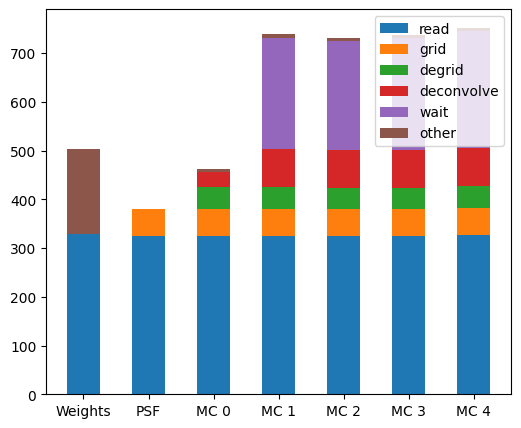

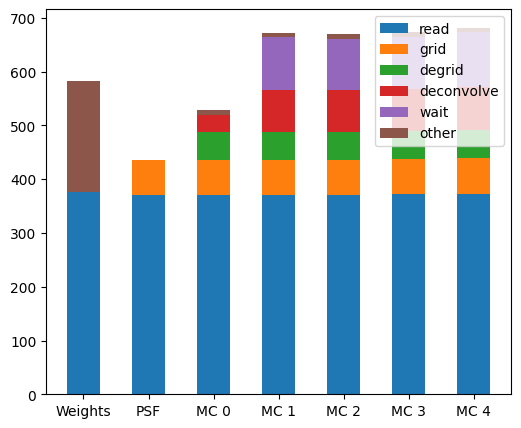

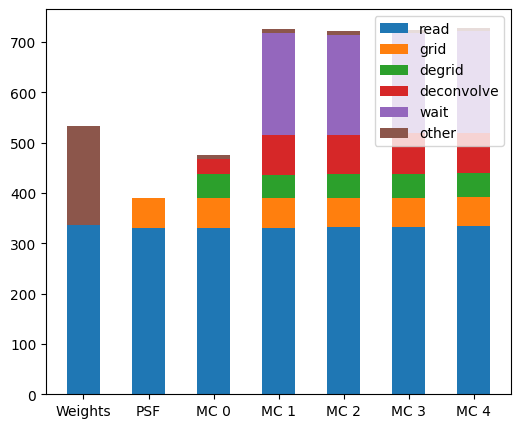

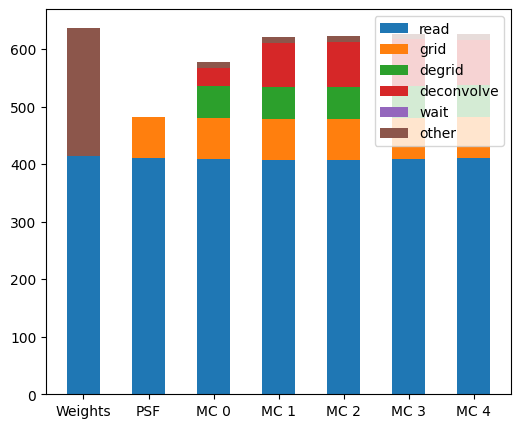

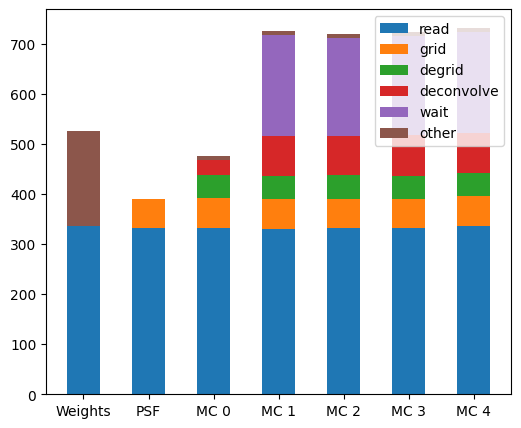

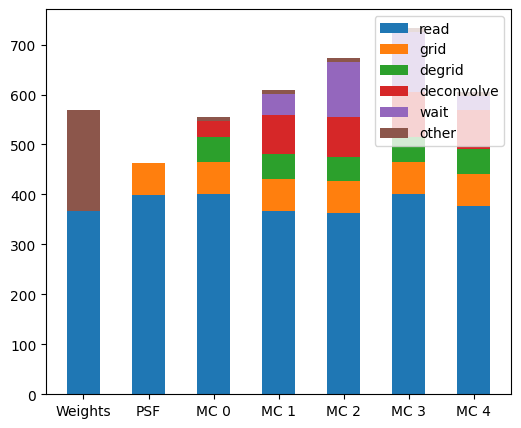

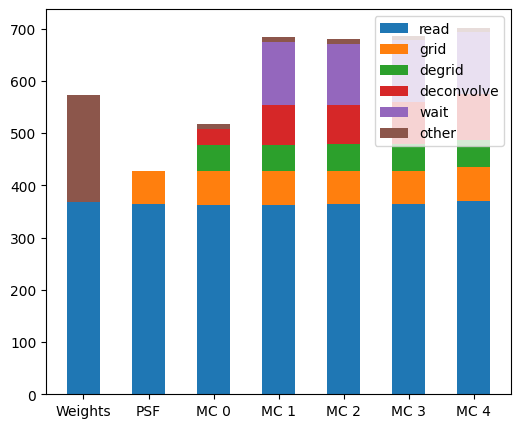

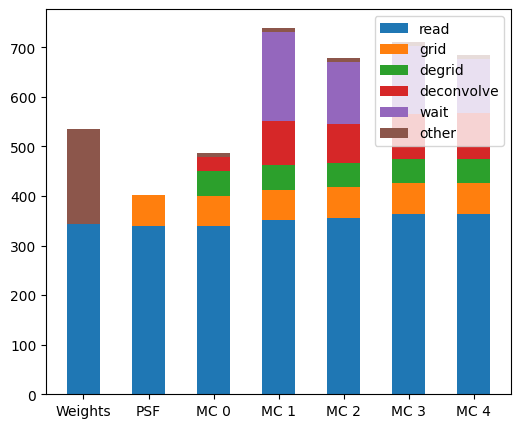

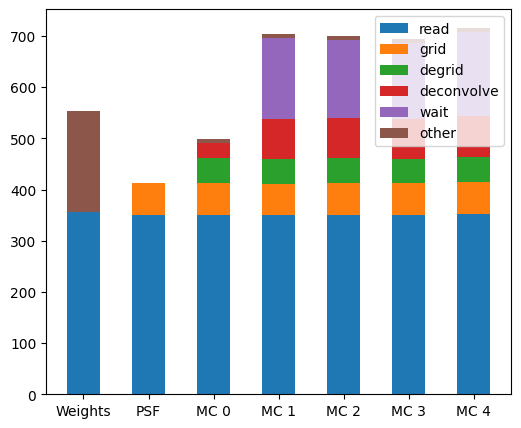

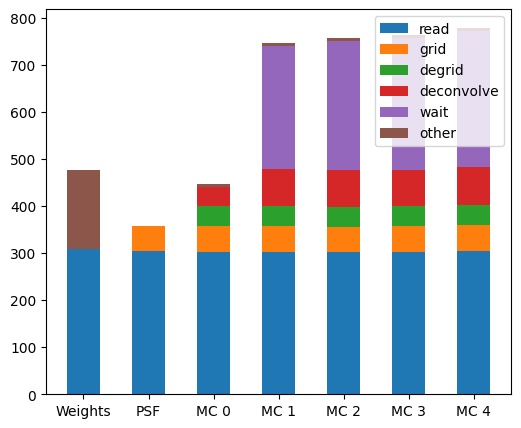

In [19]:
#Parallel l1

sgrb10_pl1_timings = []

for pl1_node in pl1_breakdown_data:
    breakdown_data = []
    for i, lst in enumerate(pl1_node):
        breakdown_data.append(list(map(float, lst)))
    
    weights_timings = breakdown_data[1]
    psf_timings = breakdown_data[2]
    wait_timings = breakdown_data[3]
    mc_timings = breakdown_data[4:]
    
    width = 0.5
    
    labels = [
        "Weights",
        "PSF"
    ]
        
    bottom = numpy.zeros(len(mc_timings) + 2)
        
    fig, ax = plt.subplots()
    
    timings = []
    timings.append([weights_timings[0], 0, 0, 0, 0, sum(weights_timings[1:])])
    timings.append([psf_timings[0], psf_timings[3], 0, 0, 0, sum(psf_timings[1:2]) + psf_timings[4]])
    
    for i, curr_mc_timings in enumerate(mc_timings):
        labels.append("MC " + str(i))
        other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
        timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                        curr_mc_timings[0] + curr_mc_timings[10], other_timings])
        
    for i, curr_breakdown in enumerate(breakdowns_parallel):
        curr_breakdown_timing = []
        for curr_timing in timings:
            curr_breakdown_timing.append(curr_timing[i])
    
        p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
        bottom += curr_breakdown_timing
        
    sgrb10_pl1_timings.append(total_timings(timings, breakdowns_parallel))
        
    ax.legend(loc="upper right")
    plt.show()

## 15 partitions SGRA

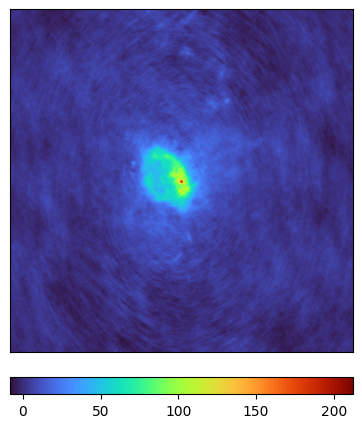

In [20]:
sgra_res_path = "../results/multi_partition_bda_results/SGRA_full_averaged_"
sgra15_res_path = "../results/multi_partition_bda_results/SGRA_full_averaged15_"

pl1_breakdown_data = []
pmsc_breakdown_data = []

partitions=["<9", "7-12", "11-15", "13-18", "17-24", "22-28", "26-33", "32-44", "42-49", "47-58", "56-72", "71-87", "85-107", "105-130", ">130"]
num_partitions = len(partitions)

for i in range(num_partitions):
    pl1_breakdown_data.append(util.read_csv(sgra15_res_path + "pl1/mc_timings_breakdown_" + str(i), separate_rows=True))

serial_breakdown_data = util.read_csv(sgra_res_path + "seriall1/mc_timings_breakdown", separate_rows=True)

dirty = util.fromfits(sgra_res_path + "seriall1/residual_0.fits")
util.plotNImages([dirty], [""], cmap="turbo", hide_ticks=True)

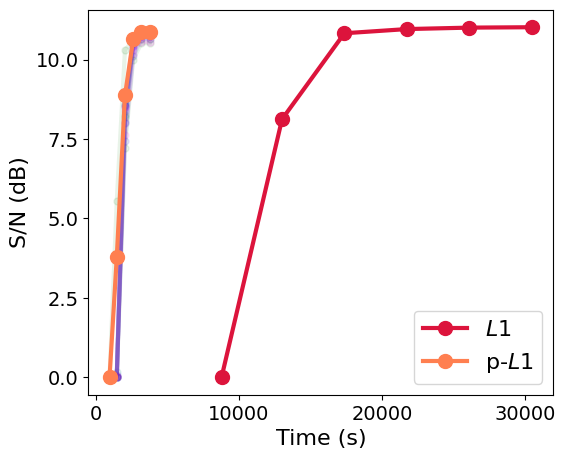

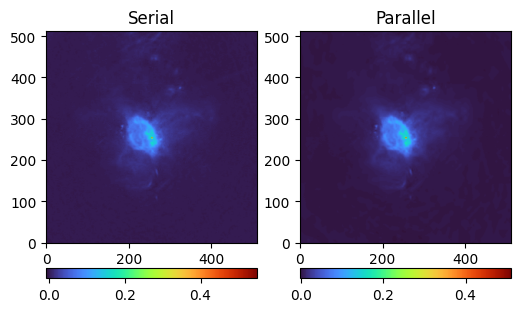

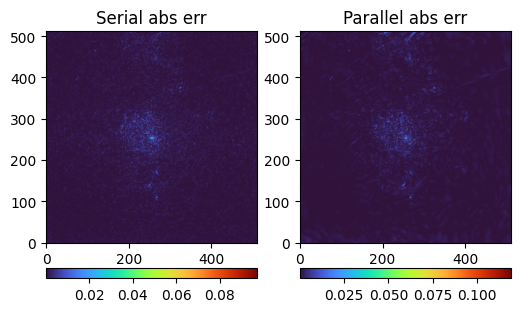

In [21]:
serial_times_sep = util.read_csv(sgra_res_path + "seriall1/mc_timings")
serial_times = []
serial_snrs = []

parallel_times_sep = util.read_csv(sgra15_res_path + "pl1/mc_timings")
parallel_times = []
parallel_snrs = []
combined_snrs = []

best_parallel_recon = None
best_serial_recon = None
best_parallel_snr = -9999
best_serial_snr = -9999

gt = util.fromfits("../data7/SGRA_full_gt.fits")

#For serial
curr_deconv = None
time_acc = float(serial_times_sep[0])
serial_times.append(time_acc)
serial_snrs.append(0)

for i in range(0, num_mc_l1):
    curr_deconv_img = util.fromfits(sgra_res_path + "seriall1/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(serial_times_sep[i+1])
    
    serial_snrs.append(evaluation.compute_snr(gt, curr_deconv))
    serial_times.append(time_acc)
    
    if best_serial_snr < serial_snrs[-1]:
        best_serial_recon = curr_deconv.copy()
        best_serial_snr = serial_snrs[-1]
    
    
#parallel
curr_deconvs = [None for i in range(num_partitions)]
time_acc = float(parallel_times_sep[0])
parallel_times.append(time_acc)
for i in range(num_partitions):
    parallel_snrs.append([0])

combined_snrs.append(0)

for i in range(0, num_mc_l1):
    for j in range(num_partitions):
        curr_deconv = util.fromfits(sgra15_res_path + "pl1/deconv_" + str(j) + "_" + str(i) + ".fits")
        if curr_deconvs[j] is None:
            curr_deconvs[j] = curr_deconv
        else:
            curr_deconvs[j] += curr_deconv
            
        parallel_snrs[j].append(evaluation.compute_snr(gt, curr_deconvs[j]))

    time_acc += float(parallel_times_sep[i+1])

    curr_deconv_combined = util.fromfits(sgra15_res_path + "pl1/recon_combined_" + str(i) + ".fits")
    combined_snrs.append(evaluation.compute_snr(gt, curr_deconv_combined))
    
    parallel_times.append(time_acc)
    
    if best_parallel_snr < combined_snrs[-1]:
        best_parallel_recon = curr_deconv_combined.copy()
        best_parallel_snr = combined_snrs[-1]

sgra_total_times.append(parallel_times[-1])
    
for i, p_snrs in enumerate(parallel_snrs):
    plt.plot(parallel_times, parallel_snrs[i], c=pcols[i], lw=3, alpha=0.1, marker='o', markersize=5)
    
plt.plot(serial_times, serial_snrs, c='crimson', label="$L1$", lw=3, marker='o', markersize=10)
plt.plot(parallel_times, combined_snrs, c='coral', label="p-$L1$", lw=3, marker='o', markersize=10)



plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)
#plt.yscale('log')
plt.legend(loc="lower right", fontsize=16)
plt.locator_params(nbins=5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig("../figures/recon15part.png", pad_inches=0.0, bbox_inches='tight')

util.plotNImages([best_serial_recon, best_parallel_recon], ["Serial", "Parallel"], same_scale=False, cmap=cmap)
util.plotNImages([numpy.abs(gt - best_serial_recon), numpy.abs(gt - best_parallel_recon)], \
                    ["Serial abs err", "Parallel abs err"], same_scale=False, cmap=cmap)

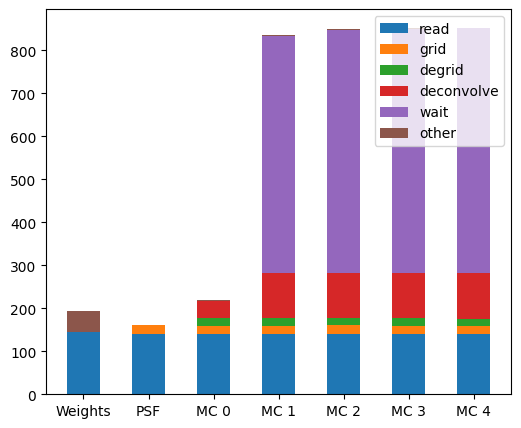

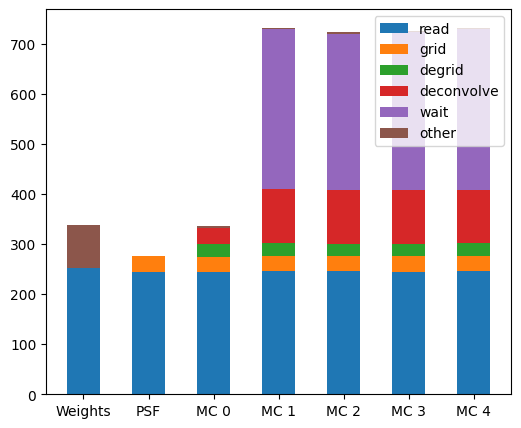

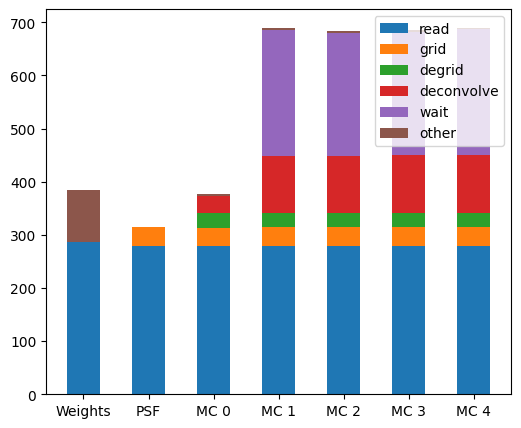

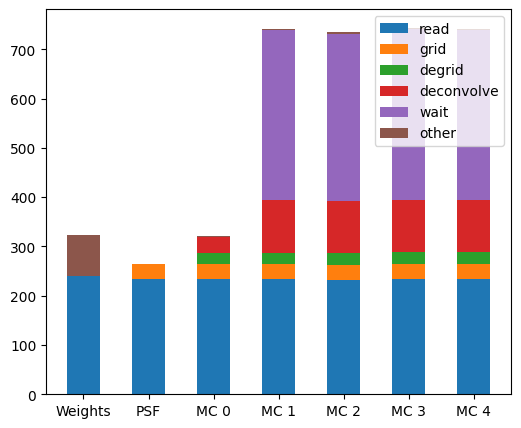

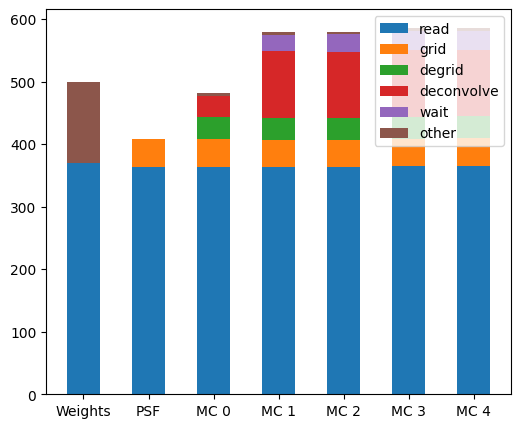

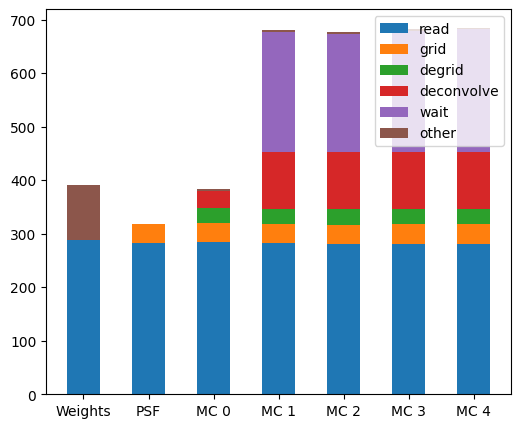

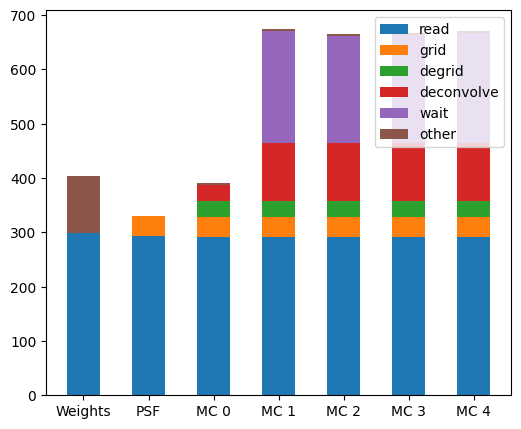

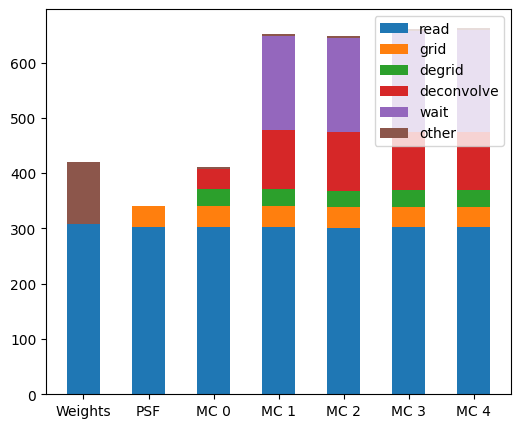

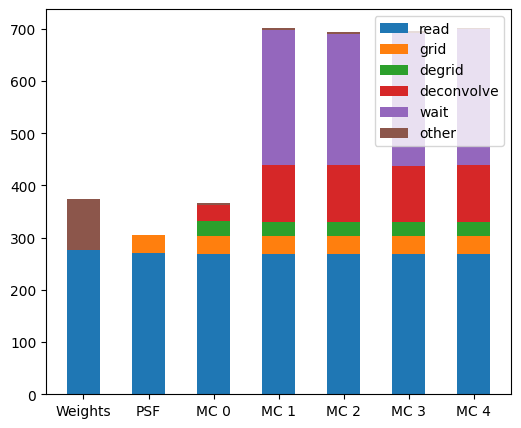

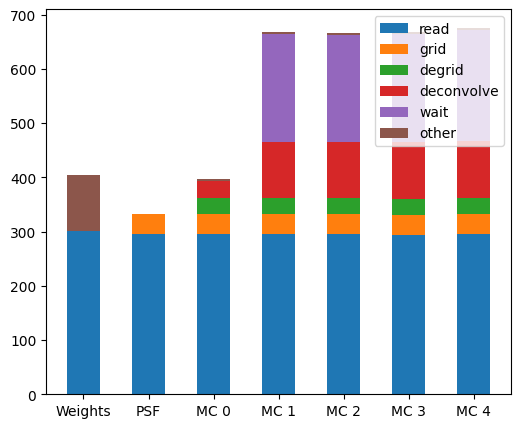

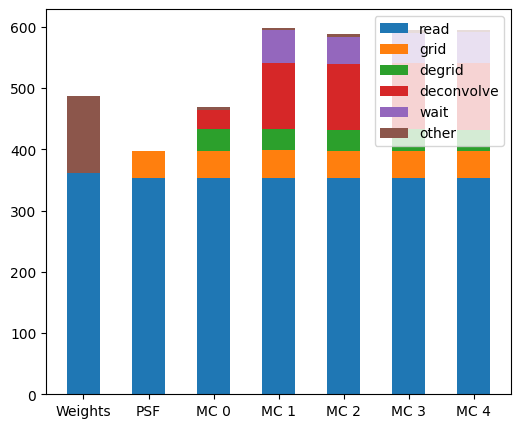

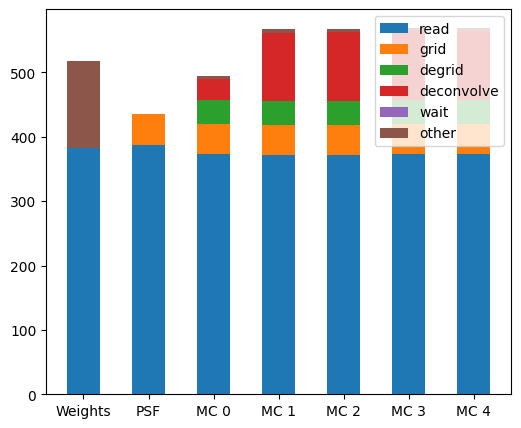

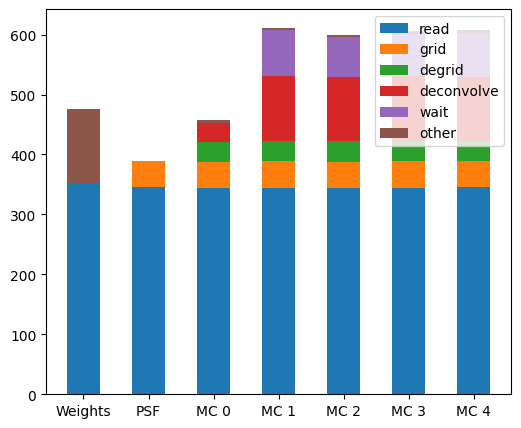

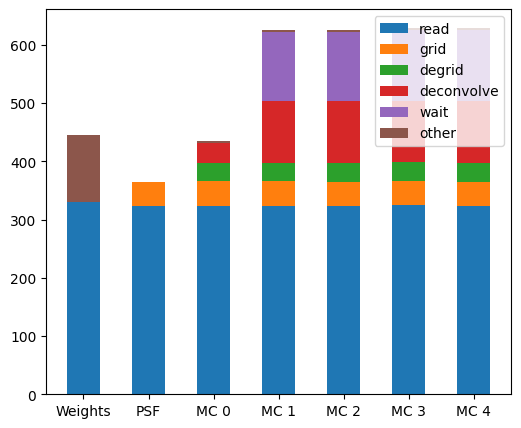

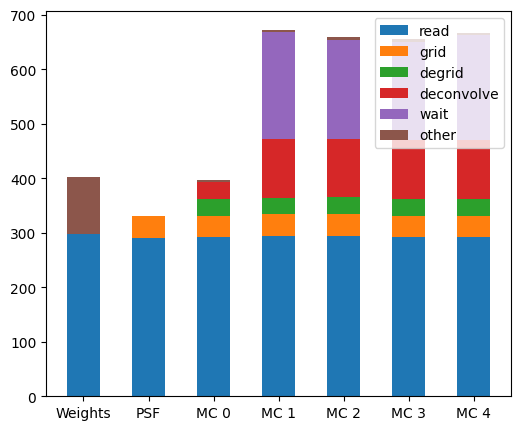

In [22]:
#Parallel l1

sgra15_pl1_timings = []

for pl1_node in pl1_breakdown_data:
    breakdown_data = []
    for i, lst in enumerate(pl1_node):
        breakdown_data.append(list(map(float, lst)))
    
    weights_timings = breakdown_data[1]
    psf_timings = breakdown_data[2]
    wait_timings = breakdown_data[3]
    mc_timings = breakdown_data[4:]
    
    width = 0.5
    
    labels = [
        "Weights",
        "PSF"
    ]
        
    bottom = numpy.zeros(len(mc_timings) + 2)
        
    fig, ax = plt.subplots()
    
    timings = []
    timings.append([weights_timings[0], 0, 0, 0, 0, sum(weights_timings[1:])])
    timings.append([psf_timings[0], psf_timings[3], 0, 0, 0, sum(psf_timings[1:2]) + psf_timings[4]])
    
    for i, curr_mc_timings in enumerate(mc_timings):
        labels.append("MC " + str(i))
        other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
        timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                        curr_mc_timings[0] + curr_mc_timings[10], other_timings])
        
    for i, curr_breakdown in enumerate(breakdowns_parallel):
        curr_breakdown_timing = []
        for curr_timing in timings:
            curr_breakdown_timing.append(curr_timing[i])
    
        p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
        bottom += curr_breakdown_timing
        
    sgra15_pl1_timings.append(total_timings(timings, breakdowns_parallel))
        
    ax.legend(loc="upper right")
    plt.show()

## SGRB 15 partitions

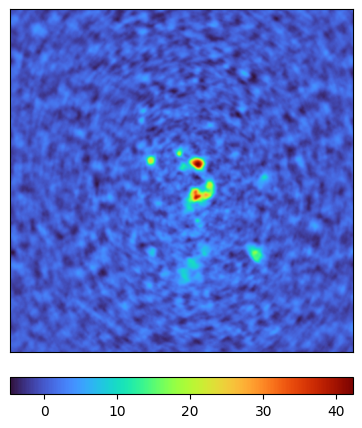

In [23]:
sgrb_res_path = "../results/multi_partition_bda_results/SGRB_full_averaged_"
sgrb15_res_path = "../results/multi_partition_bda_results/SGRB_full_averaged15_"

pl1_breakdown_data = []
pmsc_breakdown_data = []
20, 26, 34, 41, 46, 53, 56, 65, 72, 78, 91, 96, 120, 139
partitions=["<21", "19-27", "25-35", "33-42", "40-47", "45-54", "52-57", "56-66", "65-73", "71-79", "77-92", "90-97", "95-121", "119-140", ">138"]
num_partitions = len(partitions)

for i in range(num_partitions):
    pl1_breakdown_data.append(util.read_csv(sgrb15_res_path + "pl1/mc_timings_breakdown_" + str(i), separate_rows=True))

serial_breakdown_data = util.read_csv(sgrb_res_path + "seriall1/mc_timings_breakdown", separate_rows=True)

dirty = util.fromfits(sgrb_res_path + "seriall1/residual_0.fits")
util.plotNImages([dirty], [""], cmap="turbo", hide_ticks=True)

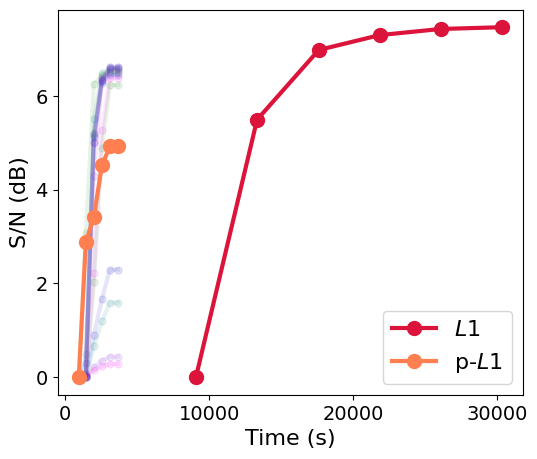

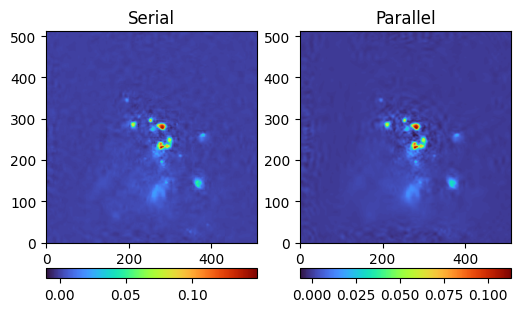

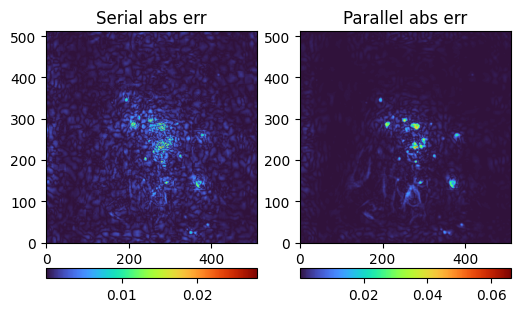

In [24]:
serial_times_sep = util.read_csv(sgrb_res_path + "seriall1/mc_timings")
serial_times = []
serial_snrs = []

parallel_times_sep = util.read_csv(sgrb15_res_path + "pl1/mc_timings")
parallel_times = []
parallel_snrs = []
combined_snrs = []

best_parallel_recon = None
best_serial_recon = None
best_parallel_snr = -9999
best_serial_snr = -9999

gt = util.fromfits("../data7/SGRB_full_gt.fits")

#For serial
curr_deconv = None
time_acc = float(serial_times_sep[0])
serial_times.append(time_acc)
serial_snrs.append(0)

for i in range(0, num_mc_l1):
    curr_deconv_img = util.fromfits(sgrb_res_path + "seriall1/deconvolved_" + str(i) + ".fits")
    if curr_deconv is None:
        curr_deconv = curr_deconv_img
    else:
        curr_deconv += curr_deconv_img
        
    time_acc += float(serial_times_sep[i+1])
    
    serial_snrs.append(evaluation.compute_snr(gt, curr_deconv))
    serial_times.append(time_acc)
    
    if best_serial_snr < serial_snrs[-1]:
        best_serial_recon = curr_deconv.copy()
        best_serial_snr = serial_snrs[-1]
    
    
#parallel
curr_deconvs = [None for i in range(num_partitions)]
time_acc = float(parallel_times_sep[0])
parallel_times.append(time_acc)
for i in range(num_partitions):
    parallel_snrs.append([0])

combined_snrs.append(0)

for i in range(0, num_mc_l1):
    for j in range(num_partitions):
        curr_deconv = util.fromfits(sgrb15_res_path + "pl1/deconv_" + str(j) + "_" + str(i) + ".fits")
        if curr_deconvs[j] is None:
            curr_deconvs[j] = curr_deconv
        else:
            curr_deconvs[j] += curr_deconv
            
        parallel_snrs[j].append(evaluation.compute_snr(gt, curr_deconvs[j]))

    time_acc += float(parallel_times_sep[i+1])

    curr_deconv_combined = util.fromfits(sgrb15_res_path + "pl1/recon_combined_" + str(i) + ".fits")
    combined_snrs.append(evaluation.compute_snr(gt, curr_deconv_combined))
    
    parallel_times.append(time_acc)
    
    if best_parallel_snr < combined_snrs[-1]:
        best_parallel_recon = curr_deconv_combined.copy()
        best_parallel_snr = combined_snrs[-1]

sgrb_total_times.append(parallel_times[-1])
    
for i, p_snrs in enumerate(parallel_snrs):
    plt.plot(parallel_times, parallel_snrs[i], c=pcols[i], lw=3, alpha=0.1, marker='o', markersize=5)
    
plt.plot(serial_times, serial_snrs, c='crimson', label="$L1$", lw=3, marker='o', markersize=10)
plt.plot(parallel_times, combined_snrs, c='coral', label="p-$L1$", lw=3, marker='o', markersize=10)



plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("S/N (dB)", fontsize=16)
#plt.yscale('log')
plt.legend(loc="lower right", fontsize=16)
plt.locator_params(nbins=5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig("../figures/recon15partb.png", pad_inches=0.0, bbox_inches='tight')

util.plotNImages([best_serial_recon, best_parallel_recon], ["Serial", "Parallel"], same_scale=False, cmap=cmap)
util.plotNImages([numpy.abs(gt - best_serial_recon), numpy.abs(gt - best_parallel_recon)], \
                    ["Serial abs err", "Parallel abs err"], same_scale=False, cmap=cmap)

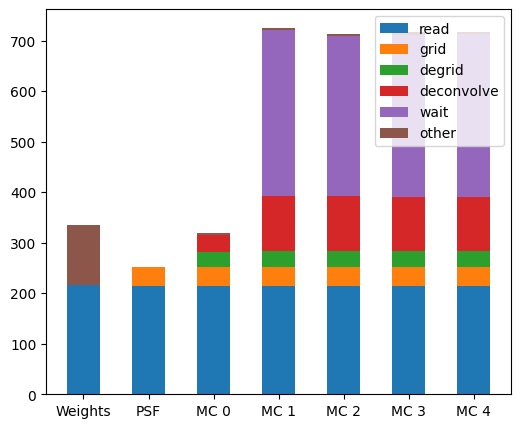

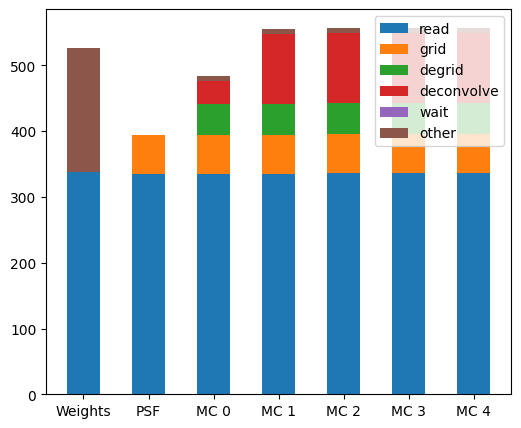

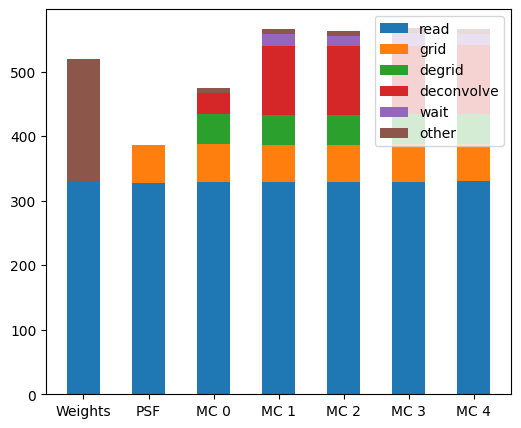

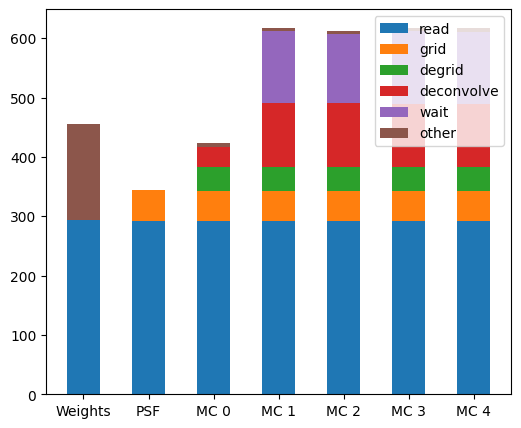

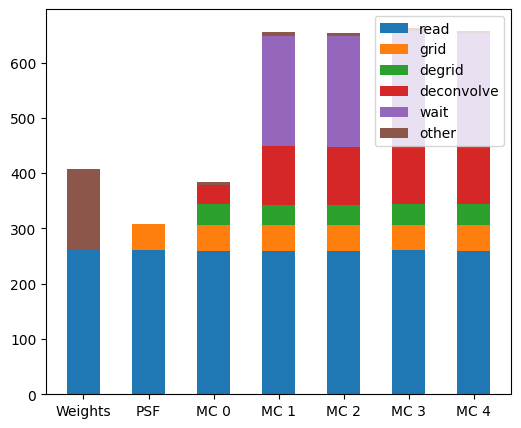

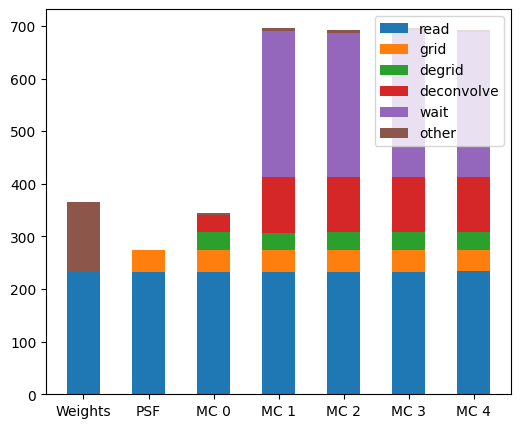

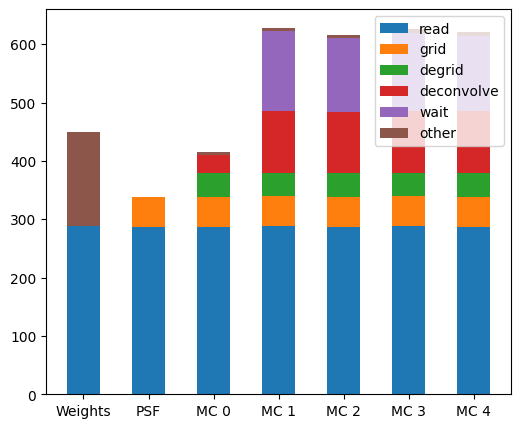

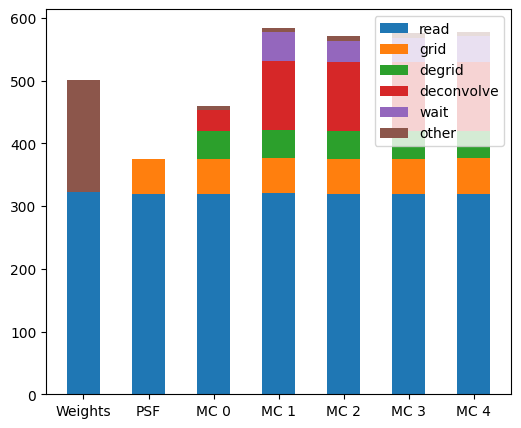

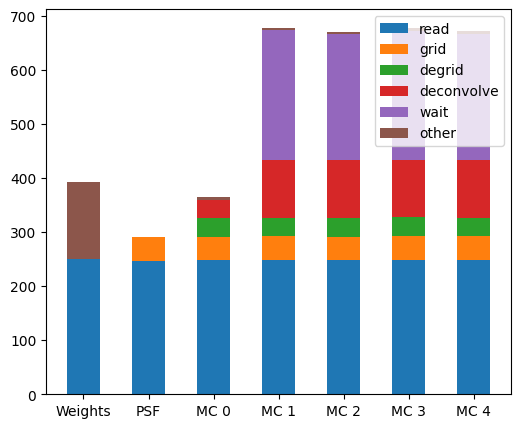

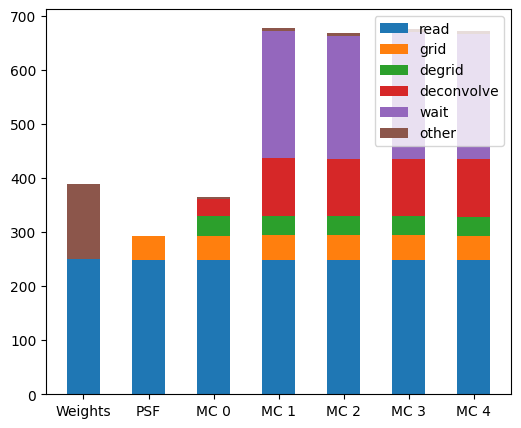

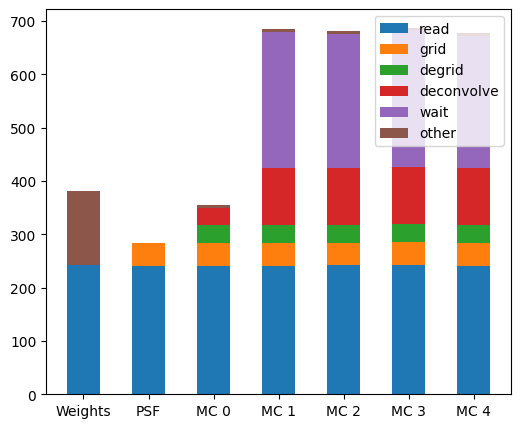

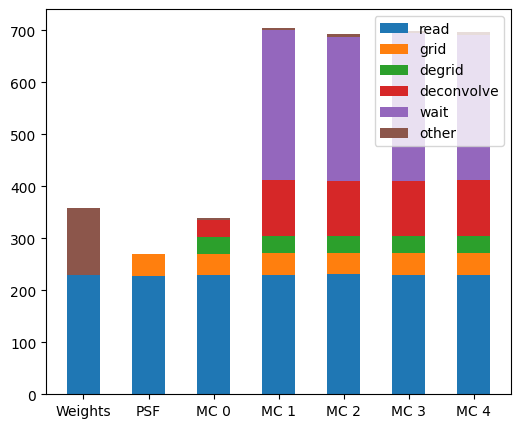

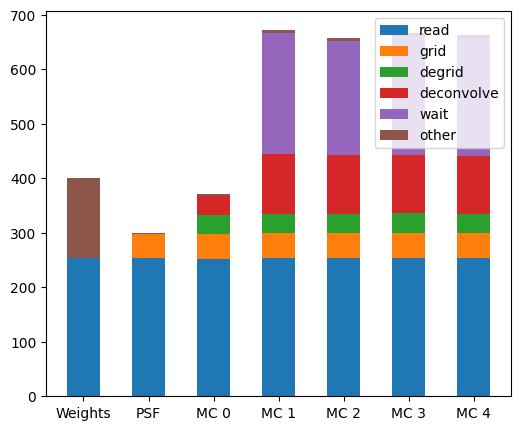

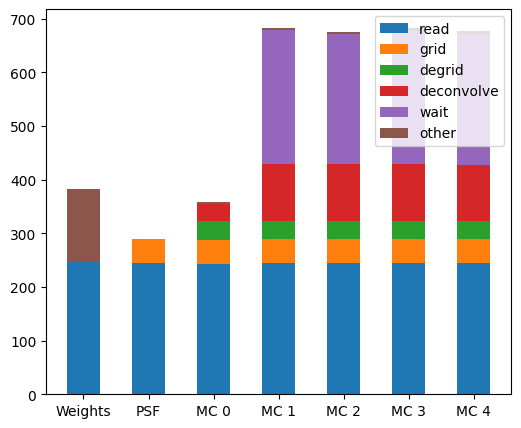

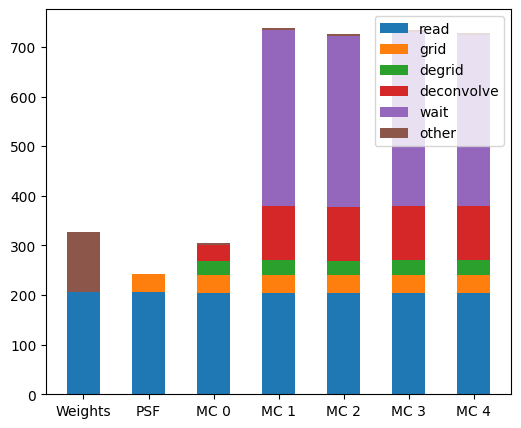

In [25]:
#Parallel l1

sgrb15_pl1_timings = []

for pl1_node in pl1_breakdown_data:
    breakdown_data = []
    for i, lst in enumerate(pl1_node):
        breakdown_data.append(list(map(float, lst)))
    
    weights_timings = breakdown_data[1]
    psf_timings = breakdown_data[2]
    wait_timings = breakdown_data[3]
    mc_timings = breakdown_data[4:]
    
    width = 0.5
    
    labels = [
        "Weights",
        "PSF"
    ]
        
    bottom = numpy.zeros(len(mc_timings) + 2)
        
    fig, ax = plt.subplots()
    
    timings = []
    timings.append([weights_timings[0], 0, 0, 0, 0, sum(weights_timings[1:])])
    timings.append([psf_timings[0], psf_timings[3], 0, 0, 0, sum(psf_timings[1:2]) + psf_timings[4]])
    
    for i, curr_mc_timings in enumerate(mc_timings):
        labels.append("MC " + str(i))
        other_timings = sum(curr_mc_timings[2:5]) + curr_mc_timings[6] + curr_mc_timings[8]
        timings.append([curr_mc_timings[1], curr_mc_timings[7], curr_mc_timings[5], curr_mc_timings[9], \
                        curr_mc_timings[0] + curr_mc_timings[10], other_timings])
        
    for i, curr_breakdown in enumerate(breakdowns_parallel):
        curr_breakdown_timing = []
        for curr_timing in timings:
            curr_breakdown_timing.append(curr_timing[i])
    
        p = ax.bar(labels, curr_breakdown_timing, width, label=curr_breakdown, bottom=bottom)
        bottom += curr_breakdown_timing
        
    sgrb15_pl1_timings.append(total_timings(timings, breakdowns_parallel))
        
    ax.legend(loc="upper right")
    plt.show()

## Comparing scaling to number of nodes in terms of computational time

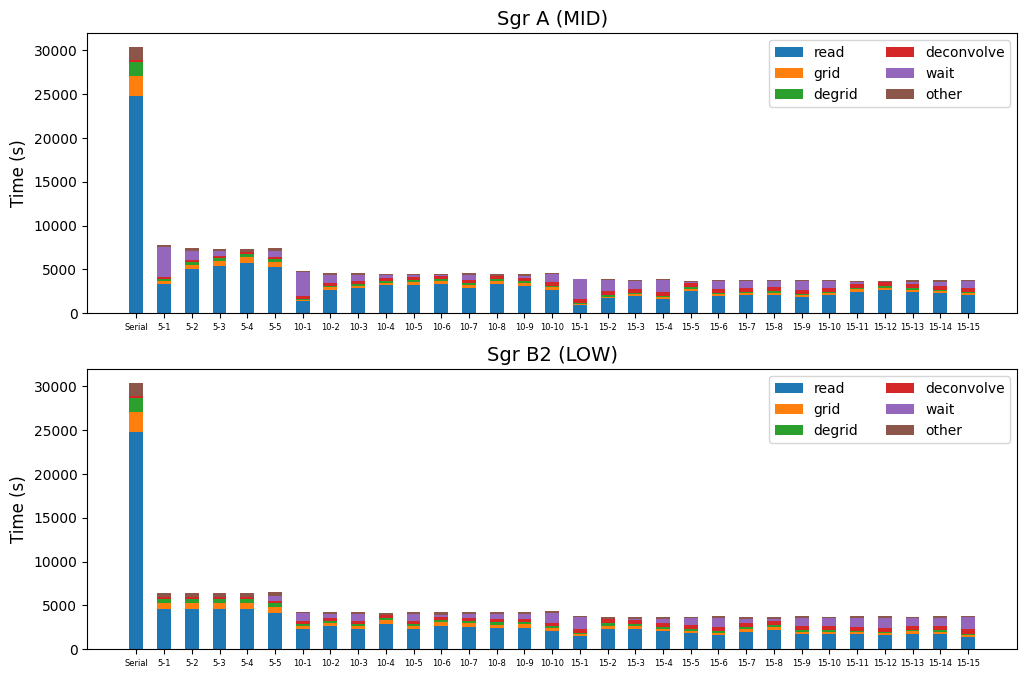

In [26]:
matplotlib.rcParams['figure.figsize'] = [12, 8]
labels=["Serial"]
labels += ["5-1", "5-2", "5-3", "5-4", "5-5"]
labels += ["10-1", "10-2", "10-3", "10-4", "10-5", "10-6", "10-7", "10-8", "10-9", "10-10"]
labels += ["15-1", "15-2", "15-3", "15-4", "15-5", "15-6", "15-7", "15-8", "15-9", "15-10", "15-11", "15-12", "15-13", "15-14", "15-15"]

mask = numpy.array([True, \
                    True, True, True, True, True, \
                    True, True, True, True, True, True, True, True, True, True, \
                    True, True, True, True, True, True, True, True, True, True, True, True, True, True, True])

fig, axes = plt.subplots(2, 1)

bottom = numpy.zeros(31)

for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_timings = None
    if i == 4:
        curr_timings = [0]
    elif i > 4:
        curr_timings = [sgra_timings_serial[i - 1]]
    else:
        curr_timings = [sgra_timings_serial[i]]
    
    for t in sgra_pl1_timings:
        curr_timings.append(t[i])
    for t in sgra10_pl1_timings:
        curr_timings.append(t[i])
    for t in sgra15_pl1_timings:
        curr_timings.append(t[i]) 
        
    p = axes[0].bar(numpy.array(labels)[mask], numpy.array(curr_timings)[mask], width, label=curr_breakdown, bottom=bottom[mask])
    bottom += curr_timings

axes[0].set_title('Sgr A (MID)', fontsize=14)
axes[0].legend(loc="upper right", fontsize=10, ncol=2)
axes[0].set_ylabel('Time (s)', fontsize=12)
axes[0].xaxis.set_tick_params(labelsize=6)
    
bottom = numpy.zeros(31)

for i, curr_breakdown in enumerate(breakdowns_parallel):
    curr_timings = None
    if i == 4:
        curr_timings = [0]
    elif i > 4:
        curr_timings = [sgra_timings_serial[i - 1]]
    else:
        curr_timings = [sgra_timings_serial[i]]
    
    for t in sgrb_pl1_timings:
        curr_timings.append(t[i])
    for t in sgrb10_pl1_timings:
        curr_timings.append(t[i])
    for t in sgrb15_pl1_timings:
        curr_timings.append(t[i]) 
        
    p = axes[1].bar(numpy.array(labels)[mask], numpy.array(curr_timings)[mask], width, label=curr_breakdown, bottom=bottom[mask])
    bottom += curr_timings
    
axes[1].set_title('Sgr B2 (LOW)', fontsize=14)
axes[1].legend(loc="upper right", fontsize=10, ncol=2)
axes[1].set_ylabel('Time (s)', fontsize=12)
axes[1].xaxis.set_tick_params(labelsize=6)

plt.savefig("../figures/breakdown.png", pad_inches=0.0, bbox_inches='tight')

## Speedup factors

In [27]:
matplotlib.rcParams['figure.figsize'] = [6, 5]

configs=["serial", "5 partitions", "10 partitions", "15 partitions"]

sgra_times = []
sgrb_times = []

print("Sgr A:")
for i, time in enumerate(sgra_total_times):
    print(configs[i] + ": " + str(time) + " (" + str(sgra_total_times[0] / time) + ")")
    sgra_times.append(sgra_total_times[0] / time)

print("Sgr B:")
for i, time in enumerate(sgrb_total_times):
    print(configs[i] + ": " + str(time) + " (" + str(sgrb_total_times[0] / time) + ")")
    sgrb_times.append(sgrb_total_times[0] / time)

Sgr A:
serial: 30479.89006781578 (1.0)
5 partitions: 7399.77406167984 (4.119029826283165)
10 partitions: 4541.020386457443 (6.712123592026826)
15 partitions: 3772.697984457016 (8.079069725005455)
Sgr B:
serial: 30300.98830652237 (1.0)
5 partitions: 6510.80224275589 (4.6539561757133905)
10 partitions: 4240.394116640091 (7.145795290021672)
15 partitions: 3669.6639816761017 (8.257156093262397)


## Lots of waiting time, check number of visibilities per partition

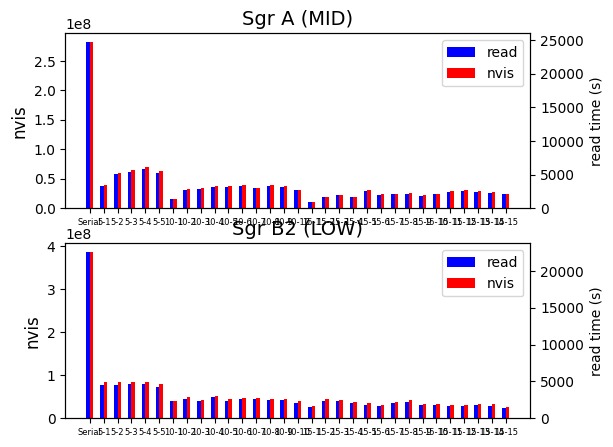

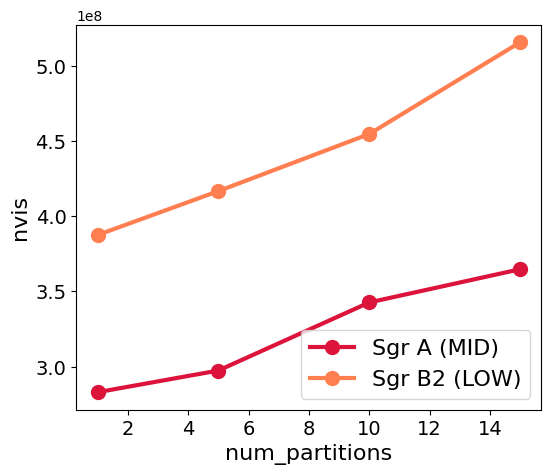

Largest ratios Sgr A: [1.         4.07544612 7.07132944 9.0166598 ]
Largest ratios Sgr B2: [1.         4.56083932 7.3815222  8.72985946]


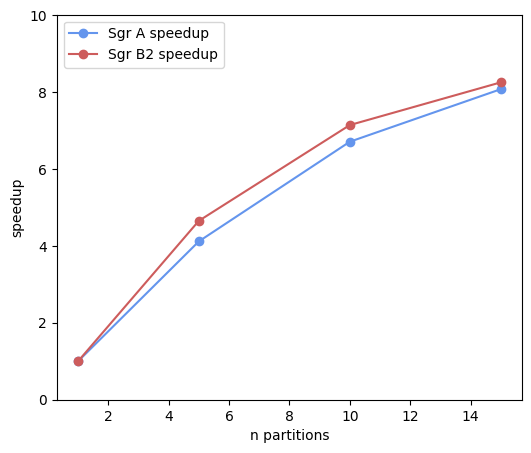

In [28]:
#full
sgra_full_vis = [283018272]
sgrb_full_vis = [387501674]

#5 partitions
sgra_5_vis = [38988766, 59594840, 65460197, 69444734, 63939502]
sgrb_5_vis = [84435102, 84360597, 84962799, 84306522, 78597233]

#10 partitions
sgra_10_vis = [16071841, 32121280, 34026297, 38174349, 38187280, 39235206, 35037865, 40023347, 38027394, 31791172]
sgrb_10_vis = [41096285, 48599339, 43574531, 52496174, 43720798, 47138443, 47803556, 44968032, 45863649, 39378524]

#15 partitions
sgra_15_vis = [11451587, 19940561, 22917922, 19283017, 30464097, 23658099, 24295833, 25182777, 22364702, 24359485, 29489767, 31388372, 28598806, 26980256, 24397540]
sgrb_15_vis = [27942874, 44388077, 43338816, 37929612, 34378738, 30610022, 37824355, 41818092, 32307294, 32372186, 31693668, 30140815, 32773105, 32043226, 26071762]

all_sgra_vis = numpy.array(sgra_full_vis + sgra_5_vis + sgra_10_vis + sgra_15_vis)
all_sgrb_vis = numpy.array(sgrb_full_vis + sgrb_5_vis + sgrb_10_vis + sgrb_15_vis)

read_timings_sgra = [sgra_timings_serial[0]]
    
for t in sgra_pl1_timings:
    read_timings_sgra.append(t[0])
for t in sgra10_pl1_timings:
    read_timings_sgra.append(t[0])
for t in sgra15_pl1_timings:
    read_timings_sgra.append(t[0])

read_timings_sgrb = [sgrb_timings_serial[0]]
    
for t in sgrb_pl1_timings:
    read_timings_sgrb.append(t[0])
for t in sgrb10_pl1_timings:
    read_timings_sgrb.append(t[0])
for t in sgrb15_pl1_timings:
    read_timings_sgrb.append(t[0])

mask = numpy.array([True, \
                    True, True, True, True, True, \
                    True, True, True, True, True, True, True, True, True, True, \
                    True, True, True, True, True, True, True, True, True, True, True, True, True, True, True])

x_vals = numpy.arange(numpy.array(all_sgra_vis)[mask].shape[0])

fig, axes = plt.subplots(2, 1)

axes[0].bar(x_vals+width/4, all_sgra_vis[mask], width/2, color='r', label='nvis')

twinax = axes[0].twinx()
twinax.bar(x_vals - width/4, numpy.array(read_timings_sgra)[mask], width/2, color='b', label='read')
twinax.set_ylabel("read time (s)")

axes[0].set_title('Sgr A (MID)', fontsize=14)
axes[0].legend(loc="upper right", fontsize=10, ncol=2)
axes[0].set_ylabel('nvis', fontsize=12)
axes[0].xaxis.set_tick_params(labelsize=6)

axes[0].set_xticks(x_vals)
axes[0].set_xticklabels(numpy.array(labels)[mask])

handles1, labels1 = twinax.get_legend_handles_labels()
handles2, labels2 = axes[0].get_legend_handles_labels()
axes[0].legend(handles1 + handles2, labels1 + labels2, loc='upper right')

axes[1].bar(x_vals + width/4, all_sgrb_vis[mask], width/2, color='r', label='nvis')

twinax2 = axes[1].twinx()
twinax2.bar(x_vals - width/4, numpy.array(read_timings_sgrb)[mask], width/2, color='b', label='read')
twinax2.set_ylabel("read time (s)")

axes[1].set_title('Sgr B2 (LOW)', fontsize=14)
axes[1].legend(loc="upper right", fontsize=10, ncol=2)
axes[1].set_ylabel('nvis', fontsize=12)
axes[1].xaxis.set_tick_params(labelsize=6)

axes[1].set_xticks(x_vals)
axes[1].set_xticklabels(numpy.array(labels)[mask])

handles1, labels1 = twinax2.get_legend_handles_labels()
handles2, labels2 = axes[1].get_legend_handles_labels()
axes[1].legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.show()

sgra_inc = [sgra_full_vis[0], numpy.sum(numpy.array(sgra_5_vis)), numpy.sum(numpy.array(sgra_10_vis)), numpy.sum(numpy.array(sgra_15_vis))]
sgrb_inc = [sgrb_full_vis[0], numpy.sum(numpy.array(sgrb_5_vis)), numpy.sum(numpy.array(sgrb_10_vis)), numpy.sum(numpy.array(sgrb_15_vis))]
partitions = [1, 5, 10, 15]

plt.plot(partitions, sgra_inc, c='crimson', label="Sgr A (MID)", lw=3, marker='o', markersize=10)
plt.plot(partitions, sgrb_inc, c='coral', label="Sgr B2 (LOW)", lw=3, marker='o', markersize=10)
plt.xlabel("num_partitions", fontsize=16)
plt.ylabel("nvis", fontsize=16)
plt.legend(loc="lower right", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

largest_ratio_sgra = sgra_full_vis[0] / numpy.array([sgra_full_vis[0], numpy.max(sgra_5_vis), numpy.max(sgra_10_vis), numpy.max(sgra_15_vis)])
largest_ratio_sgrb = sgrb_full_vis[0] / numpy.array([sgrb_full_vis[0], numpy.max(sgrb_5_vis), numpy.max(sgrb_10_vis), numpy.max(sgrb_15_vis)])

alim = numpy.max(largest_ratio_sgra)
blim = numpy.max(largest_ratio_sgrb)

ylim = numpy.max([alim, blim])

print("Largest ratios Sgr A: " + str(largest_ratio_sgra))
print("Largest ratios Sgr B2: " + str(largest_ratio_sgrb))

x=[1, 5, 10, 15]

fig, ax1 = plt.subplots()
# ax2 = ax1.twinx()
ax1.plot(x, sgra_times, label="Sgr A speedup", c="cornflowerblue", marker='o')
ax1.plot(x, sgrb_times, label="Sgr B2 speedup", c="indianred", marker='o')
ax1.set_xlabel("n partitions")
ax1.set_ylabel("speedup")
ax1.set_ylim(bottom=0, top=(ylim+1))
ax1.legend(loc="upper left")

# ax2.plot(x, largest_ratio_sgra, label="Sgr A vis ratio", c="mediumblue", marker='o')
# ax2.plot(x, largest_ratio_sgrb, label="Sgr B2 vis ratio", c="crimson", marker='o')
# ax2.set_ylabel("$vis_{total}/max(vis_n)$")
# ax2.set_ylim(bottom=0, top=ylim+1)
# ax2.legend(loc="lower right")

plt.savefig("../figures/scaling.png", pad_inches=0.0, bbox_inches='tight')

## Improved partitioning, compare with previous

### Sgr A 10 partitions

2025-12-12 13:43:23	SEVERE	open::../data8/10partitions_balanced/SGRA_full_averaged13.ms	Exception Reported: Table ../data8/10partitions_balanced/SGRA_full_averaged13.ms does not exist
Traceback (most recent call last):
  File "/home/sunwang/radio-imaging/notebooks_and_pyscripts/get_ms_viscount.py", line 17, in <module>
    tb.open(ms)
  File "/home/sunwang/radio-imaging/environment/radioimaging/lib/python3.10/site-packages/casatools/table.py", line 308, in open
    return self._swigobj.open(tablename, lockoptions, nomodify)
  File "/home/sunwang/radio-imaging/environment/radioimaging/lib/python3.10/site-packages/casatools/__casac__/table.py", line 446, in open
    return _table.table_open(self, *args, **kwargs)
RuntimeError: Table ../data8/10partitions_balanced/SGRA_full_averaged13.ms does not exist
2025-12-12 13:43:23	SEVERE	open::../data8/10partitions_balanced/SGRA_full_averaged13.ms	Exception Reported: Table ../data8/10partitions_balanced/SGRA_full_averaged13.ms does not exist
Trace

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (0,) and arg 1 with shape (10,).

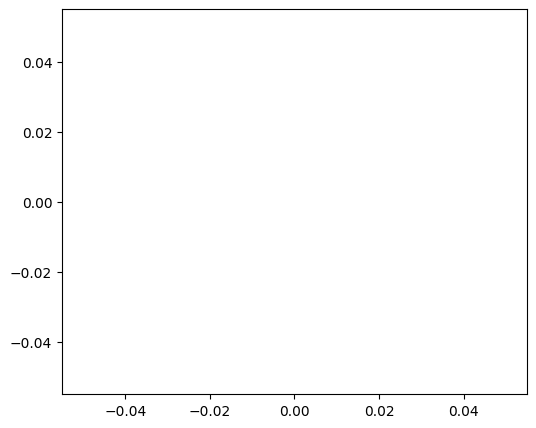

In [29]:
ms_names = ""
ells = [13, 19, 25, 31, 44, 55, 70, 89, 117]
output_name="../data8/10partitions_balanced/SGRA_full_averaged"
for ell in ells:
    ms_names += output_name + str(ell) + ".ms "

ms_names += output_name + str(ells[-1]) + "plus.ms"

command = "python get_ms_viscount.py --idatasets " + ms_names

os.system(command)
output = os.popen(command).read()

partition_counts = [int(x.strip(",")) for x in output.strip("[]\n").split()]
width = 0.5

plt.bar(numpy.array(range(len(partition_counts))) - width/4, partition_counts, width=width/2, color='r')
plt.bar(numpy.array(range(len(partition_counts))) + width/4, sgra_10_vis, width=width/2, color='b')
plt.show()

### Sgr A 15 partitions

In [ ]:
ms_names = ""
ells = [10, 14, 19, 23, 27, 31, 39, 47, 56, 68, 79, 89, 107, 130]
output_name="../data8/15partitions_balanced/SGRA_full_averaged"
for ell in ells:
    ms_names += output_name + str(ell) + ".ms "

ms_names += output_name + str(ells[-1]) + "plus.ms"

command = "python get_ms_viscount.py --idatasets " + ms_names

os.system(command)
output = os.popen(command).read()

partition_counts = [int(x.strip(",")) for x in output.strip("[]\n").split()]
width = 0.5

plt.bar(numpy.array(range(len(partition_counts))) - width/4, partition_counts, width=width/2, color='r')
plt.bar(numpy.array(range(len(partition_counts))) + width/4, sgra_15_vis, width=width/2, color='b')
plt.show()

## Sgr B2 10 partitions

In [ ]:
ms_names = ""
ells = [25, 34, 42, 52, 58, 72, 87, 96, 123]
output_name="../data8/10partitions_balanced/SGRB_full_averaged"
for ell in ells:
    ms_names += output_name + str(ell) + ".ms "

ms_names += output_name + str(ells[-1]) + "plus.ms"

command = "python get_ms_viscount.py --idatasets " + ms_names

os.system(command)
output = os.popen(command).read()

partition_counts = [int(x.strip(",")) for x in output.strip("[]\n").split()]
width = 0.5

plt.bar(numpy.array(range(len(partition_counts))) - width/4, partition_counts, width=width/2, color='r')
plt.bar(numpy.array(range(len(partition_counts))) + width/4, sgrb_10_vis, width=width/2, color='b')
plt.show()

In [ ]:
ms_names = ""
ells = [22, 27, 33, 40, 45, 53, 56, 62, 71, 78, 91, 96, 120, 139]
output_name="../data8/15partitions_balanced/SGRB_full_averaged"
for ell in ells:
    ms_names += output_name + str(ell) + ".ms "

ms_names += output_name + str(ells[-1]) + "plus.ms"

command = "python get_ms_viscount.py --idatasets " + ms_names

os.system(command)
output = os.popen(command).read()

partition_counts = [int(x.strip(",")) for x in output.strip("[]\n").split()]
width = 0.5

plt.bar(numpy.array(range(len(partition_counts))) - width/4, partition_counts, width=width/2, color='r')
plt.bar(numpy.array(range(len(partition_counts))) + width/4, sgrb_15_vis, width=width/2, color='b')
plt.show()